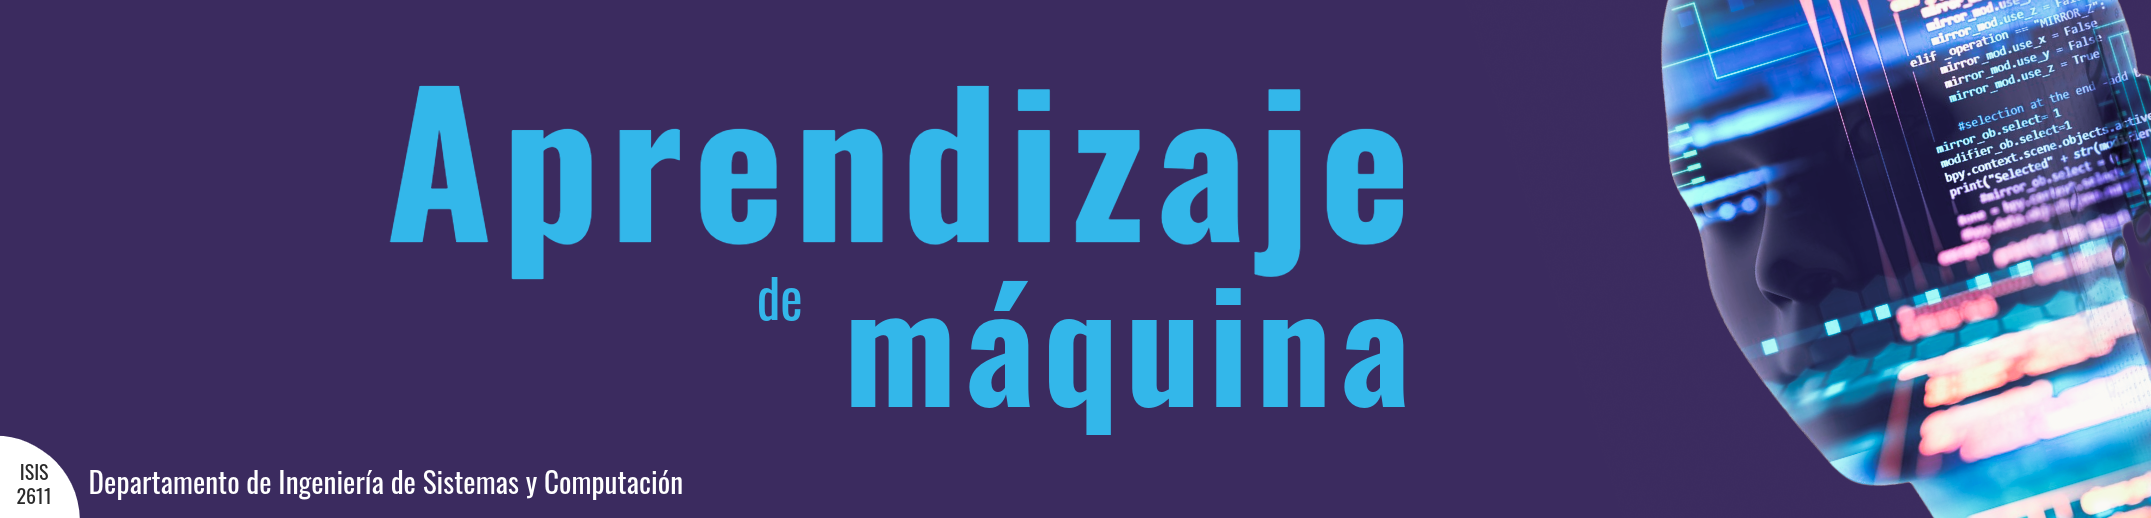


Estudiantes:

Camilo Molina – 202221119

Natalia Erazo – 202213680

# Laboratorio 1 - Exploración, preparación y regresión lineal

En este notebook se trabajará sobre el **Caso AlpesPlanck**:

El Instituto AlpesPlanck de Biogeoquímica registra variables meteorológicas cada 10 minutos en su estación de Jena, Alemania, desde 2003. Ellos han conocido el trabajo realizado por ustedes y están interesados en contratarlos para desarrollar un proyecto orientado a predecir la temperatura máxima de un día e identificar las variables metereológicas que más aportan a esa predicción, con el fin de diseñar estrategias que permitan mitigar problemas como incendios forestales o complicaciones relacionadas con fenómenos como "el Niño" o la "Niña".

Las actividades a realizar corresponden a: 
1. Exploración de los datos
2. Preparación de datos
3. Construcción de un modelo de regresión lineal
4. Evaluación cuantitativa
5. Evaluación cualitativa
6. Comunicar los resultados
7. Uso del modelo
8. Uso de herramienta de IA generativa


## 1. Exploración de los datos

Como primer paso se importan las librerías con las que se va a trabajar. Además, se revisan las versiones de las librerías a usar para propósitos de documentación. El laboratorio se resuelve utilizando las siguientes versiones:

Versión de Pandas: 2.2.3

Versión de Matplotlib: 3.9.2

Versión de Seaborn: 0.13.2


In [3]:
#%pip install pandas numpy matplotlib seaborn scikit-learn scipy openpyxl


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from importlib.metadata import version

print(f"Versión de Pandas: {version('pandas')}")
print(f"Versión de Matplotlib: {version('matplotlib')}")
print(f"Versión de Seaborn: {version('seaborn')}")

Versión de Pandas: 3.0.5
Versión de Matplotlib: 3.11.1
Versión de Seaborn: 0.13.2


### 1.1 Cargar del conjunto de datos

Se carga el archivo haciendo uso de la función read_csv().

In [5]:
datos_meteorologicos = pd.read_csv('./data/DatosLab1.csv', )

data = datos_meteorologicos.copy()

Para tener una primera visión de los datos usaremos la función head():

In [6]:
data.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


> **Observación**: la validez en los datos de 'mes' no se cumple, según las 5 primeras filas: enero se representa como JANUARY y January.

### 1.2 Estructura del dataset

Para conocer el tamaño del conjunto de datos usamos la función `shape`:

In [7]:
data.shape

(2576, 27)

Esto nos dice que el conjunto de datos está compuesto por 2576 registros y 27 variables.

Para un primer acercamiento al tipo de dato de cada columna y al conteo de datos nulos usamos `data.info()`.

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   str    
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 non-null   

> **Observación**: inicialmente se detectan valores nulos en múltiples columnas.

Identificamos las columnas específicas con valores nulos:

In [9]:
cols_con_null = []

for col in data.columns:
    if data[col].count() != len(data):
        cols_con_null.append(col)

print('Columnas con valores nulos:', cols_con_null)
print('Cantidad de columnas con nulos:', len(cols_con_null))

nulls = []

for col in cols_con_null:
    nulos = data[col].isna().sum()
    porcentaje = nulos / len(data) * 100
    
    nulls.append([col, nulos, porcentaje])

tabla_nulls = pd.DataFrame(
    nulls,
    columns=['Columna', 'Valores nulos', 'Porcentaje (%)']
)

tabla_nulls['Porcentaje (%)'] = tabla_nulls['Porcentaje (%)'].round(2)

display(tabla_nulls)

Columnas con valores nulos: ['fecha', 'presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'direccion_viento', 'registros_del_dia', 'anio', 'dia_del_anio', 'estacion_anio', 'mes', 'sector_viento', 'temp_max_manana']
Cantidad de columnas con nulos: 27


,Columna,Valores nulos,Porcentaje (%)
0,fecha,72,2.80
1,presion_media,75,2.91
2,presion_min,74,2.87
3,presion_max,64,2.48
4,presion_desv,80,3.11
5,humedad_media,74,2.87
6,humedad_min,80,3.11
7,humedad_max,86,3.34
8,humedad_desv,61,2.37
9,viento_media,86,3.34


Se evidencia que en todas las 27 columnas hay datos nulos.

Ahora se explora el diccionario de datos:

In [10]:
dict = pd.read_excel('./data/DiccionarioDeDatos.xlsx')
pd.set_option('display.max_colwidth', None)
dict

,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día (mbar).
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


Con el diccionario podemos entender el significado y rango válido de cada variable.

Se intuye:

- 'anio', 'mes' y 'dia_del_anio' deben coincidir con los datos de la columna 'fecha'.

- los datos de [varible]_media den ser mayores a [varible]_min y menores a [varible]_max.

- la estacion_anio debe coincidir con la fecha (hemisferio norte por Jena, Alemania).


Ahora clasificamos las columnas según su tipo estadístico:

In [11]:
cuantitativas_continuas = ['presion_media', 'presion_min', 'presion_max', 'presion_desv',
                           'humedad_media', 'humedad_min', 'humedad_max','humedad_desv',
                           'viento_media', 'viento_min', 'viento_max','viento_desv',
                           'rafaga_media', 'rafaga_min', 'rafaga_max','rafaga_desv',
                           'viento_norte', 'viento_este',
                           'direccion_viento']
cuantitativas_discretas = ['registros_del_dia', 'anio', 'dia_del_anio']
cualitativas_ordinales  = []
cualitativas_nominales  = ['estacion_anio', 'sector_viento', 'mes']



print("Cuantitativas continuas :", cuantitativas_continuas)
print("Cuantitativas discretas :", cuantitativas_discretas)
print("Cualitativas ordinales  :", cualitativas_ordinales)
print("Cualitativas nominales  :", cualitativas_nominales)

Cuantitativas continuas : ['presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'direccion_viento']
Cuantitativas discretas : ['registros_del_dia', 'anio', 'dia_del_anio']
Cualitativas ordinales  : []
Cualitativas nominales  : ['estacion_anio', 'sector_viento', 'mes']


### 1.3 Descripción de los datos
Para obtener mediciones estadísticas (como la media, la desviación estándar, el mínimo, el máximo y una separación por cuartiles) y una descripción más clara de los datos usamos la función `describe()`.


In [12]:
pd.set_option('display.max_columns', None)

data.describe()

,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2501.000000,2502.000000,2512.000000,2496.000000,2502.000000,2496.000000,2490.000000,2515.000000,2490.000000,2485.000000,2495.000000,2504.000000,2498.000000,2504.000000,2503.000000,2497.000000,2496.000000,2512.000000,2497.000000,2499.000000,2490.000000,2508.000000,2481.000000
mean,1010.494271,986.684409,991.704244,1.752041,52.413586,45.094067,90.236582,10.606821,3.814103,1.417799,7.647484,13.859643,2.988370,-2.639322,6.946058,-5.763253,-1.128463,-0.410159,172.104573,144.090836,2011.995582,182.690989,13.863309
std,435.334494,8.927138,7.726906,1.215931,35.975384,30.196163,10.647237,5.481338,3.307402,3.960650,6.785897,76.009623,27.846414,199.861693,3.237379,75.258134,25.065084,1.147218,86.102348,4.107365,1.999694,105.529469,9.296199
min,948.996000,913.600000,951.940000,0.226900,0.004663,0.237700,27.020000,0.000000,0.000000,0.000000,0.000000,0.000000,-1386.273300,-9999.000000,0.000000,-232.260000,-1250.463300,-3.718500,0.000000,90.000000,2009.000000,1.000000,-15.230000
25%,984.287800,981.371333,987.070000,0.899050,0.869060,1.011790,88.025000,6.082100,1.655350,0.230000,3.370000,0.757000,2.511875,0.440000,4.803198,1.002100,-1.640625,-1.236475,91.303500,144.000000,2010.000000,91.000000,7.310000
50%,989.452800,987.070000,991.935000,1.444550,68.558100,49.670000,93.300000,10.199800,2.463400,0.440000,5.051746,1.054850,3.228800,0.660000,6.690000,1.461100,-0.564300,-0.356000,199.568500,144.000000,2012.000000,182.500000,14.310000
75%,994.469000,992.567500,996.782500,2.254800,80.562600,67.665000,96.600000,14.722200,4.880505,0.960000,9.630000,1.571550,4.264600,1.120000,8.850000,2.008800,0.241525,0.316275,227.101700,144.000000,2014.000000,274.250000,20.460000
max,9939.918000,1012.320198,1013.940000,12.397500,100.000000,103.311405,100.000000,26.341600,24.753600,45.184956,45.108000,3319.030100,11.465200,19.895916,23.500000,3471.027800,4.809900,4.713900,359.796700,287.000000,2015.000000,366.000000,63.050000


#### Descripción de variables cualitativas

Usamos `describe()` con el parámetro `include='object'` para estudiar las variables de tipo `object` (categóricas / texto).

Esto nos devuelve:

- `count`: valores no nulos.
- `unique`: cuántos valores distintos existen.
- `top`: valor más frecuente (moda).
- `freq`: cuántas veces aparece ese valor.

> **Observaciones**:
> - Encontramos problemas de consistencia para estacion_anio pues hay 28 valores posibles y solo deberían ser 4.
> - Encontramos problemas de consistencia para mes pues hay 61 valores posibles y solo deberían ser 12.
> - Encontramos problemas de consistencia para sector_viento pues hay 33 valores posibles y solo deberían ser 8.


In [13]:
# Descripción de columnas cualitativas (tipo object)
data.describe(include='object')

/var/folders/r4/gt1dv7gn3x7frvp7ct9s1g_h0000gn/T/ipykernel_31037/695215392.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include='object')


,fecha,estacion_anio,mes,sector_viento
count,2504,2488,2488,2505
unique,2486,28,61,33
top,2009-01-22,primavera,May,SO
freq,2,517,127,695


In [14]:
# Revisar formatos para ver cuántas representaciones diferentes de los mismos datos hay y cuáles son

objetos = ['estacion_anio', 'mes', 'sector_viento'
] 

for i in objetos:
    print("Valores únicos en " + i + ":")
    print(data[i].unique())
    print(f"Total de valores únicos: {data[i].nunique()} \n\n")

Valores únicos en estacion_anio:
<StringArray>
[            'invierno',                 'East',                    nan,
 'Estacion_Desconocida',               'verano',             'Inverano',
            'invierno ',             'INVIERNO',      'VERANO_INVIERNO',
               'Verano',            'primavera',            'Primavera',
           'primaveraa',            'PRIMAVERA',               'berano',
               'VERANO',                'verno',                'otono',
               'otoño ',                 'fall',               'autumn',
                'OTONO',               'winter',             'invernio',
               'primav',               'spring',                'Otoño',
             'Invierno',               'summer']
Length: 29, dtype: str
Total de valores únicos: 28 


Valores únicos en mes:
<StringArray>
[   'January',       'JULY',    'JANUARY',        'May',      'Enero',
          nan,       'JUNE',        'Sep',      'April',  'SEPTEMBER',
  'noviembre',

Para conocer el número de veces que cada valor aparece en una las columnas, usamos la función `value_counts()`:


In [15]:
for i in objetos:
    display(data[i].value_counts())

estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
Otoño                    12
otoño                    11
invernio                 11
Primavera                10
PRIMAVERA                10
invierno                  9
INVIERNO                  9
Verano                    9
Invierno                  9
OTONO                     8
primav                    6
spring                    6
summer                    6
Name: count, dtype: int64

mes
May           127
August        125
July          123
January       120
March         118
             ... 
april          16
septiembre     16
junio          16
Jan            13
OCTOBER        13
Name: count, Length: 61, dtype: int64

sector_viento
SO           695
S            519
NE           424
O            308
N            124
E             77
SE            66
NO            42
Suroeste      29
so            26
SOUTHWEST     24
s             20
South         19
ne            19
NORTHEAST     17
Sur           16
Noreste       12
o              8
SOUTH          8
NORTH          6
no             6
West           5
WEST           5
North          4
East           4
EAST           4
Sureste        3
Oeste          3
Noroeste       3
SOUTHEAST      3
Norte          3
Este           2
NORTHWEST      1
Name: count, dtype: int64

### 1.4 Datos duplicados

Revisamos cuántas filas de datos se encuentran totalmente duplicadas:

In [16]:
display(data.duplicated().sum())

display(data[data.duplicated(keep=False)])

np.int64(4)

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
21,2009-01-22,9784.1150,971.48,983.54,3.9853,86.731100,69.11,97.6,9.7926,10.09692,1.440,26.532,178.43,4.2533,0.88,10.13,-122.650,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770
1412,2012-11-13,1005.3724,1002.77,1006.81,1.0690,88.175500,58.28,99.1,12.6853,4.07916,0.792,9.576,48.94,1.8189,0.40,3.80,-32.660,-0.9230,-0.2193,193.3681,144.0,2012.0,318.0,otono,abril,S,44.852
1499,2013-02-08,984.6369,983.06,987.49,1.3454,0.886056,0.76,96.8,4.6160,NaN,0.648,10.656,50.07,1.5029,0.52,5.01,-36.085,0.0254,-0.2613,275.5529,144.0,2013.0,39.0,verano,Sep,O,-0.600
1570,2013-04-20,1000.4455,998.46,1002.49,1.1632,60.748100,45.71,82.0,10.9518,17.65908,7.380,23.544,77.24,7.1450,3.72,9.41,-54.325,4.1573,2.5121,31.1426,144.0,2013.0,110.0,primavera,JANUARY,NE,61.412
2556,2013-04-20,1000.4455,998.46,1002.49,1.1632,60.748100,45.71,82.0,10.9518,17.65908,7.380,23.544,77.24,7.1450,3.72,9.41,-54.325,4.1573,2.5121,31.1426,144.0,2013.0,110.0,primavera,JANUARY,NE,61.412
2559,2012-11-13,1005.3724,1002.77,1006.81,1.0690,88.175500,58.28,99.1,12.6853,4.07916,0.792,9.576,48.94,1.8189,0.40,3.80,-32.660,-0.9230,-0.2193,193.3681,144.0,2012.0,318.0,otono,abril,S,44.852
2563,2009-01-22,9784.1150,971.48,983.54,3.9853,86.731100,69.11,97.6,9.7926,10.09692,1.440,26.532,178.43,4.2533,0.88,10.13,-122.650,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770
2565,2013-02-08,984.6369,983.06,987.49,1.3454,0.886056,0.76,96.8,4.6160,NaN,0.648,10.656,50.07,1.5029,0.52,5.01,-36.085,0.0254,-0.2613,275.5529,144.0,2013.0,39.0,verano,Sep,O,-0.600


> **Observación**: Se detectan **4 filas completamente duplicadas** que serán eliminadas en la fase de preparación.

### 1.5 Visualización de variables

#### Boxplot de variables numéricas



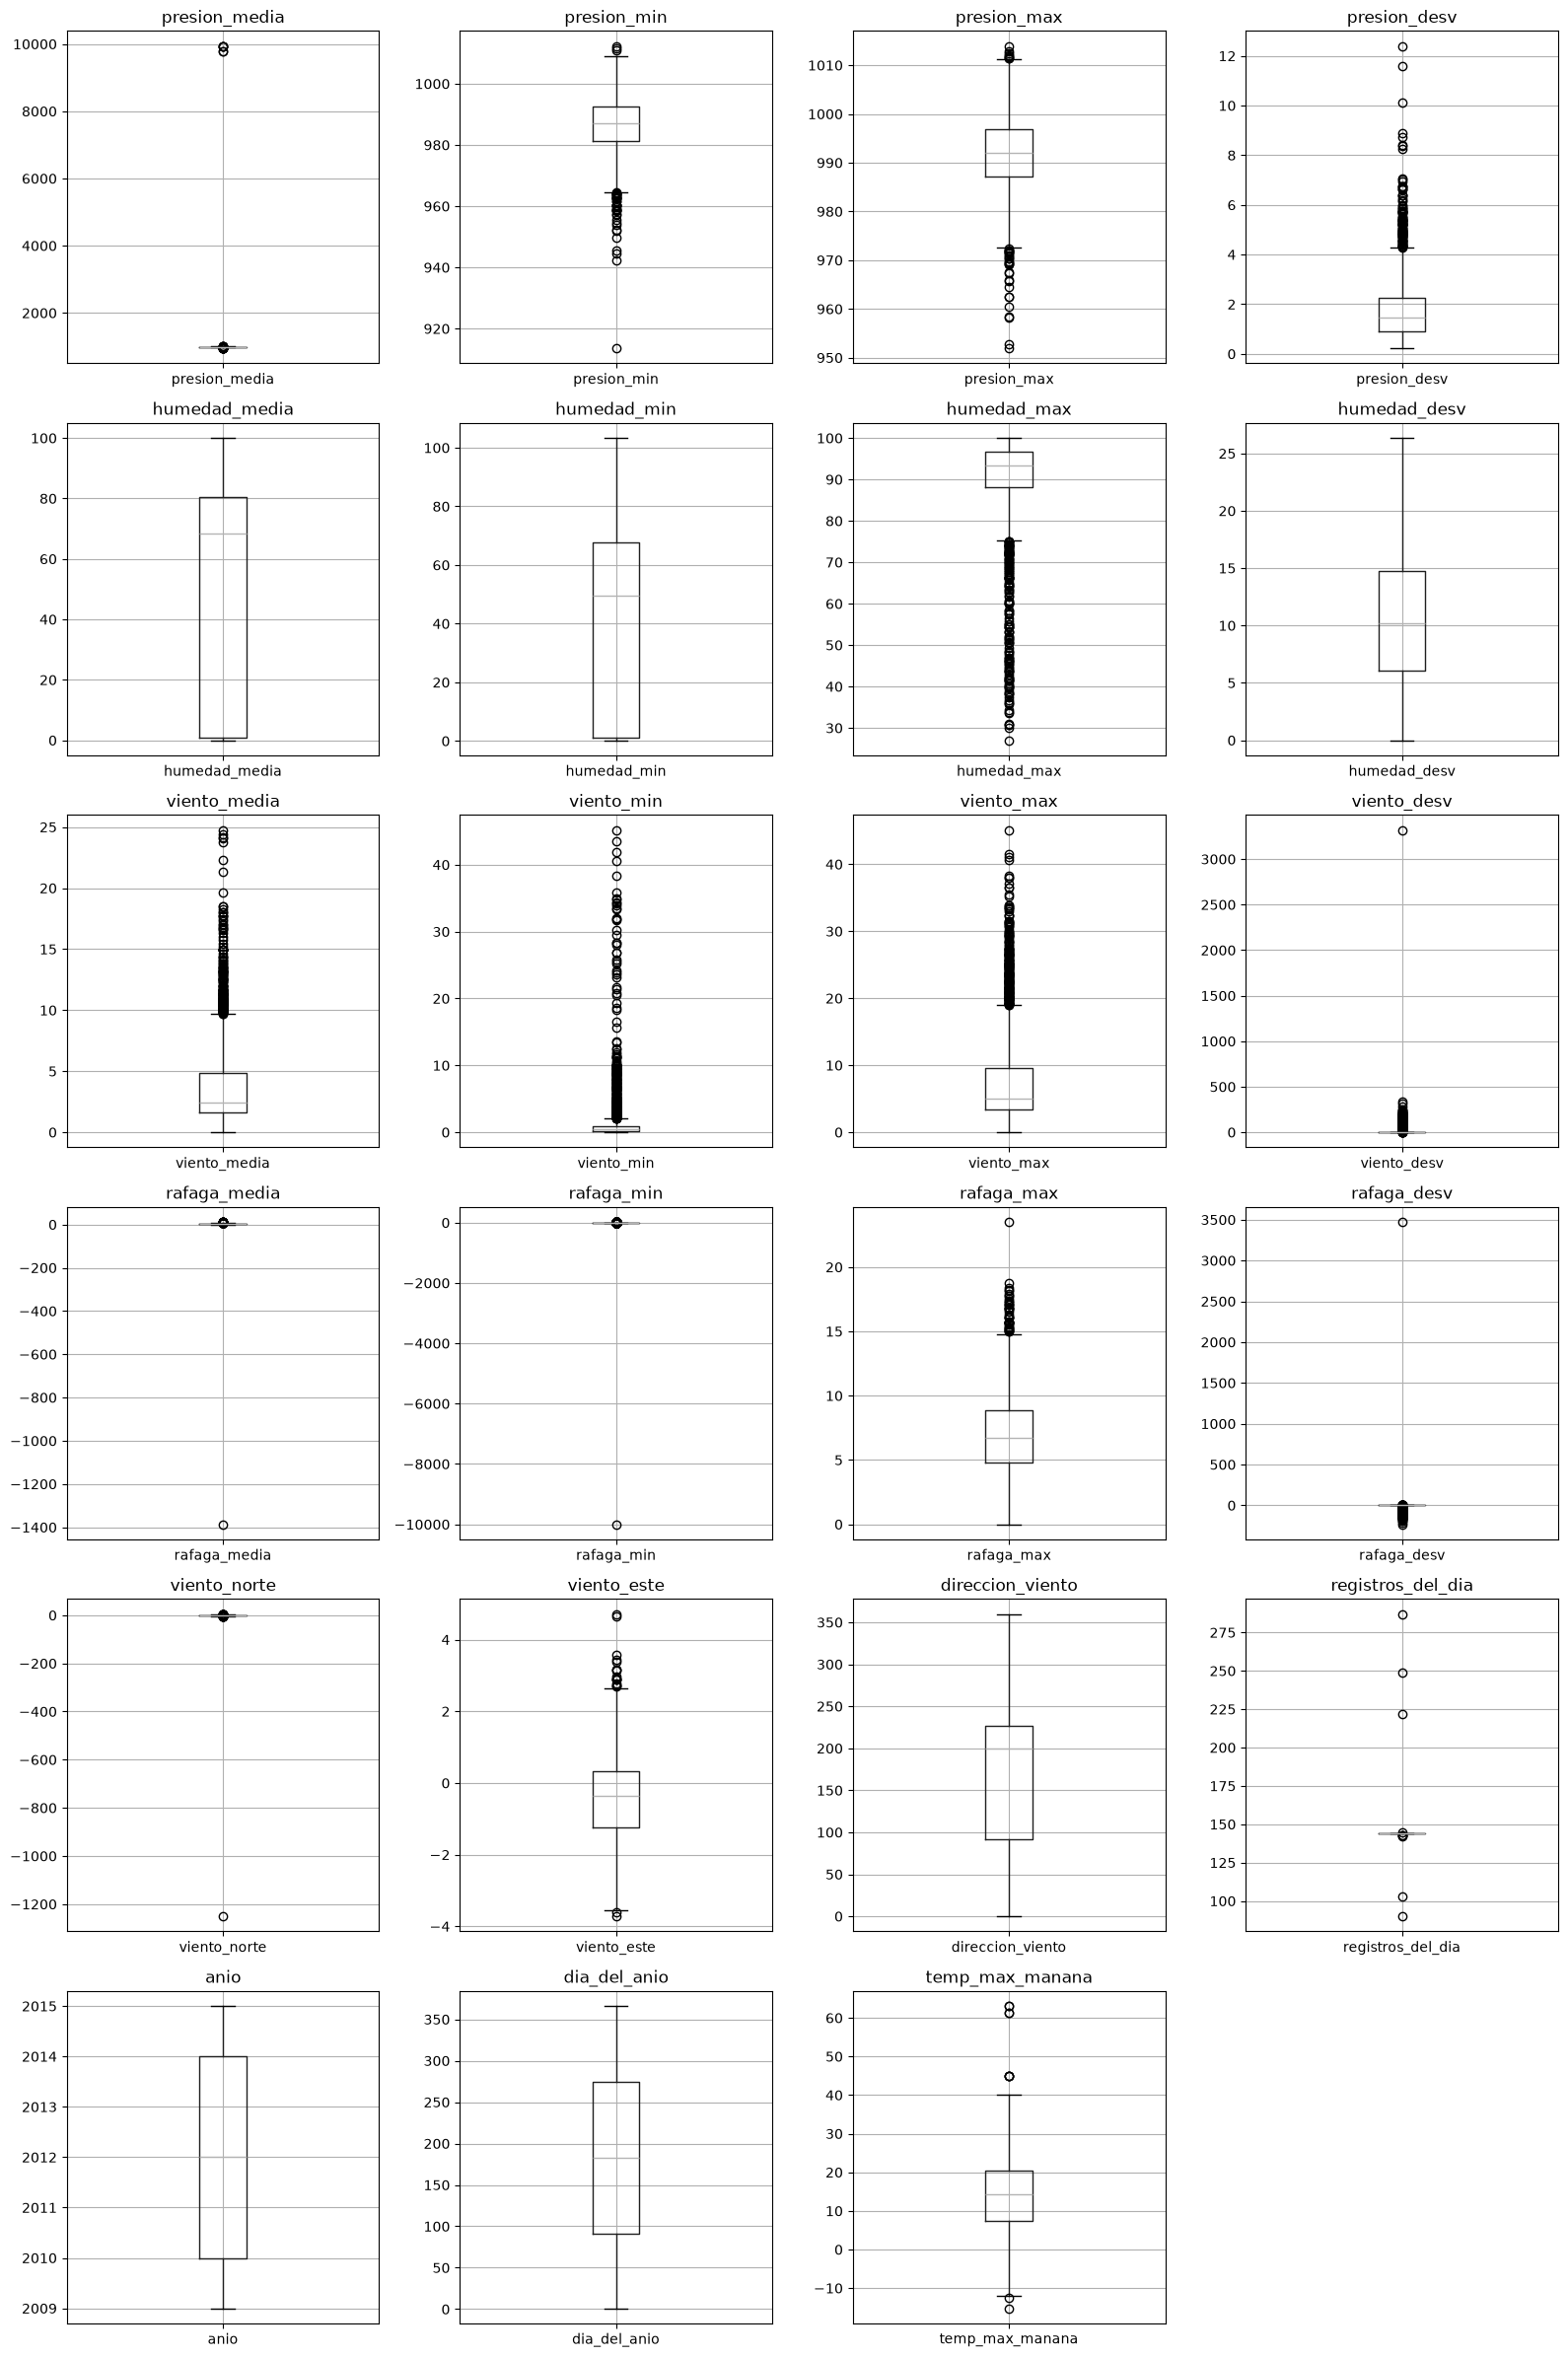

In [17]:
# Se incluyen unicamente variables numericas para los boxplots
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns

n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)

# Ocultamos graficas que sobren
for i in range(len(numeric_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

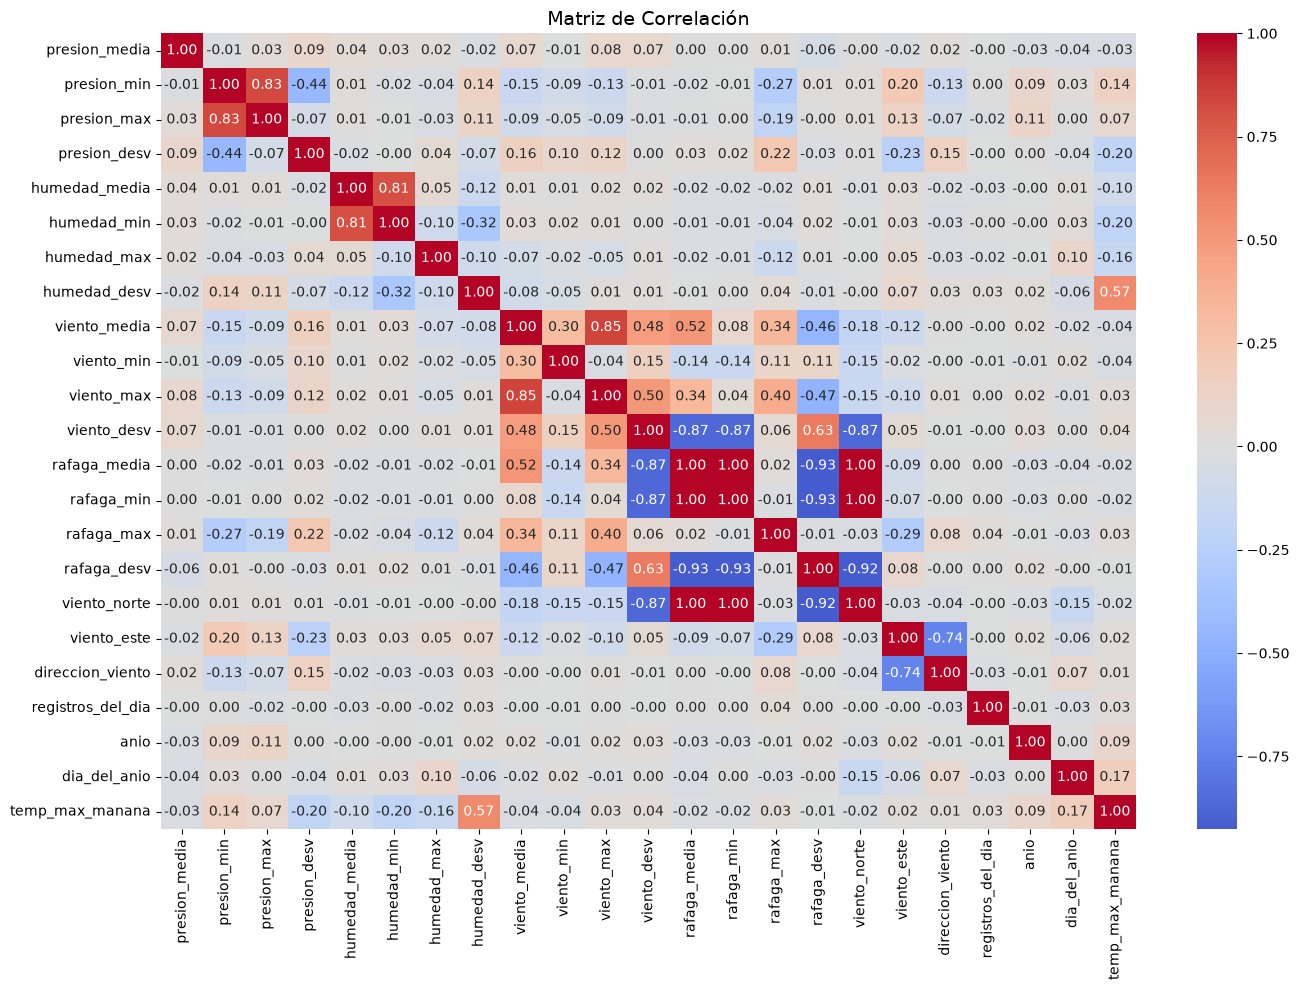

In [18]:
plt.figure(figsize=(14, 10))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación', fontsize=14)
plt.tight_layout()
plt.show()

#### Comparación de media, mínimo y máximo por Variable

Creamos gráficas comparativas para las variables principales, mostrando cómo varían la media, el mínimo y el máximo.

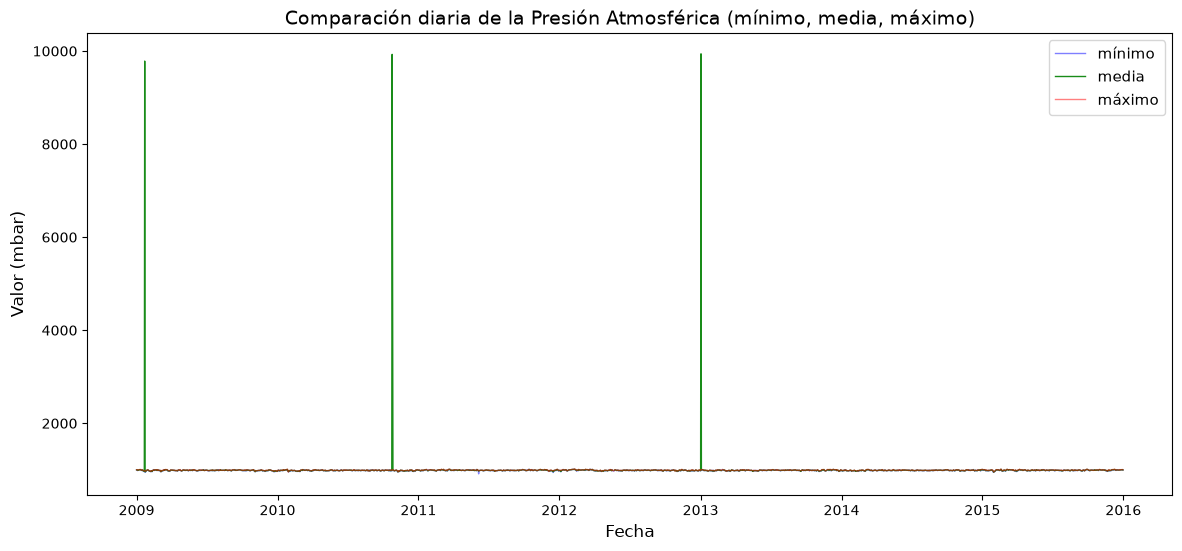

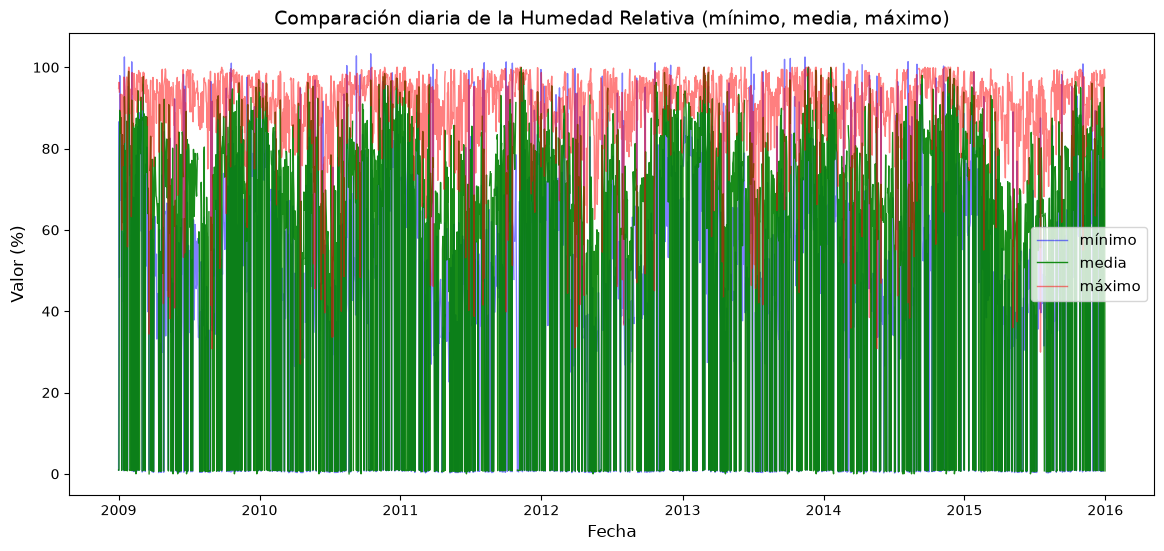

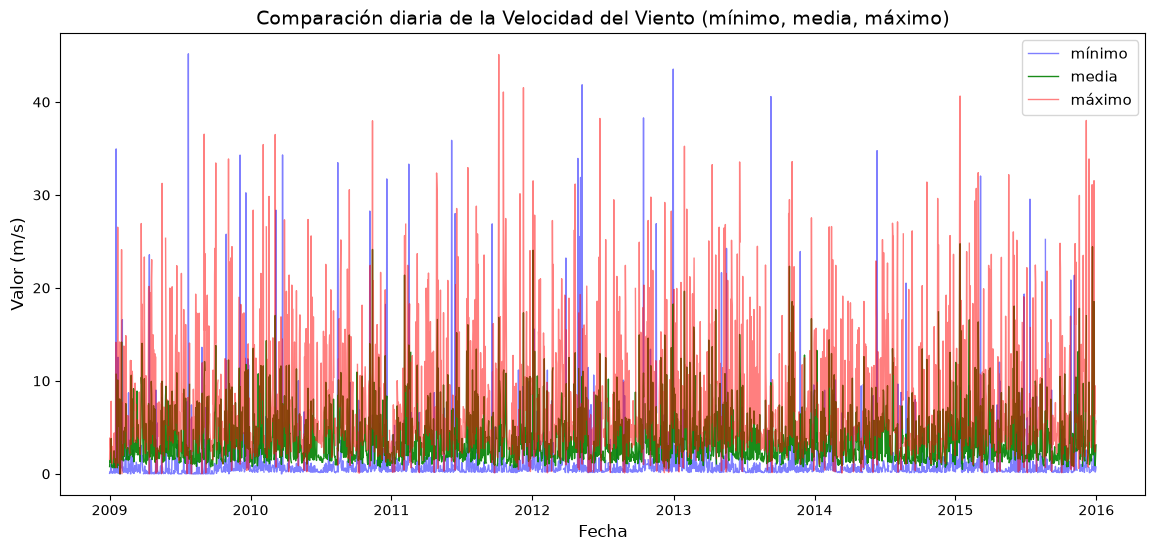

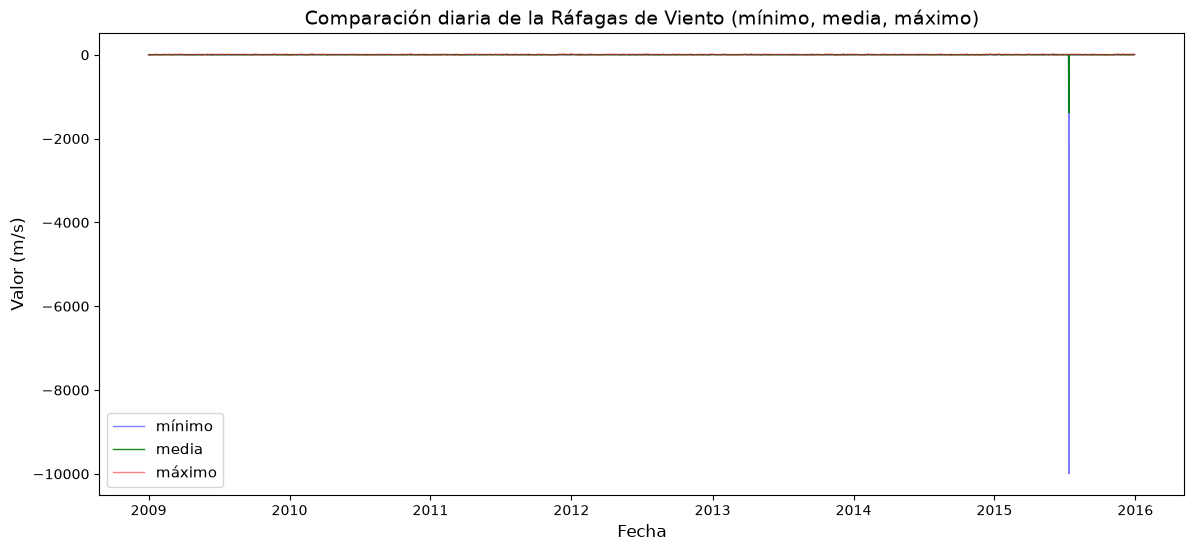

In [19]:
data['fecha'] = pd.to_datetime(data['fecha'])
data = data.sort_values('fecha')

variables = {
    'presion': ('Presión Atmosférica', 'mbar'),
    'humedad': ('Humedad Relativa', '%'),
    'viento': ('Velocidad del Viento', 'm/s'),
    'rafaga': ('Ráfagas de Viento', 'm/s')
}

colores = {
    'min': 'blue',
    'media': 'green',
    'max': 'red'
}

for variable, (titulo, unidad) in variables.items():
    plt.figure(figsize=(14, 6))

    minimo = data[variable + '_min']
    media = data[variable + '_media']
    maximo = data[variable + '_max']

    plt.plot(data['fecha'], minimo,
             label='mínimo', color=colores['min'], alpha=0.5, linewidth=1)

    plt.plot(data['fecha'], media,
             label='media', color=colores['media'], alpha=0.9, linewidth=1)

    plt.plot(data['fecha'], maximo,
             label='máximo', color=colores['max'], alpha=0.5, linewidth=1)

    plt.title(
        f'Comparación diaria de la {titulo} (mínimo, media, máximo)',
        fontsize=14
    )
    plt.xlabel('Fecha', fontsize=12)
    plt.ylabel(f'Valor ({unidad})', fontsize=12)
    plt.legend(fontsize=11)
    plt.show()

#### Frecuencias de variables

Observamos la frecuencia de las direcciones del viento.

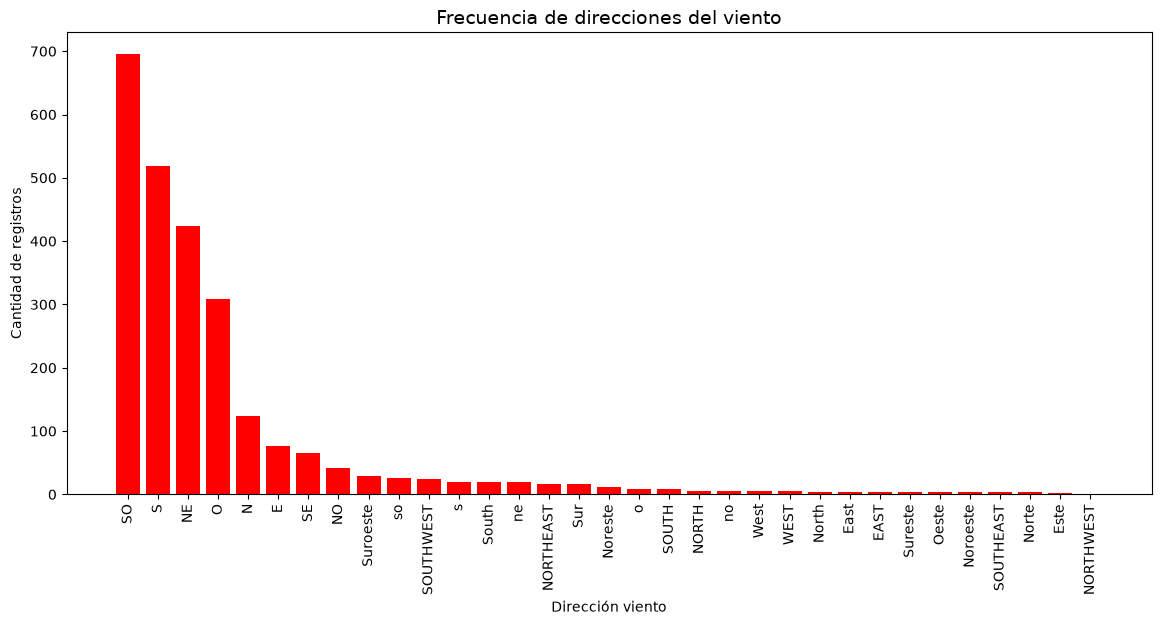

In [20]:
plt.figure(figsize=(14, 6))

viento_counts = data['sector_viento'].value_counts()

plt.bar(
    viento_counts.index,
    viento_counts.values,
    color='red'
)

plt.title('Frecuencia de direcciones del viento', fontsize=14)
plt.xlabel('Dirección viento')
plt.ylabel('Cantidad de registros')
plt.xticks(rotation=90)
plt.show()

#### Variación de temperatura por estación

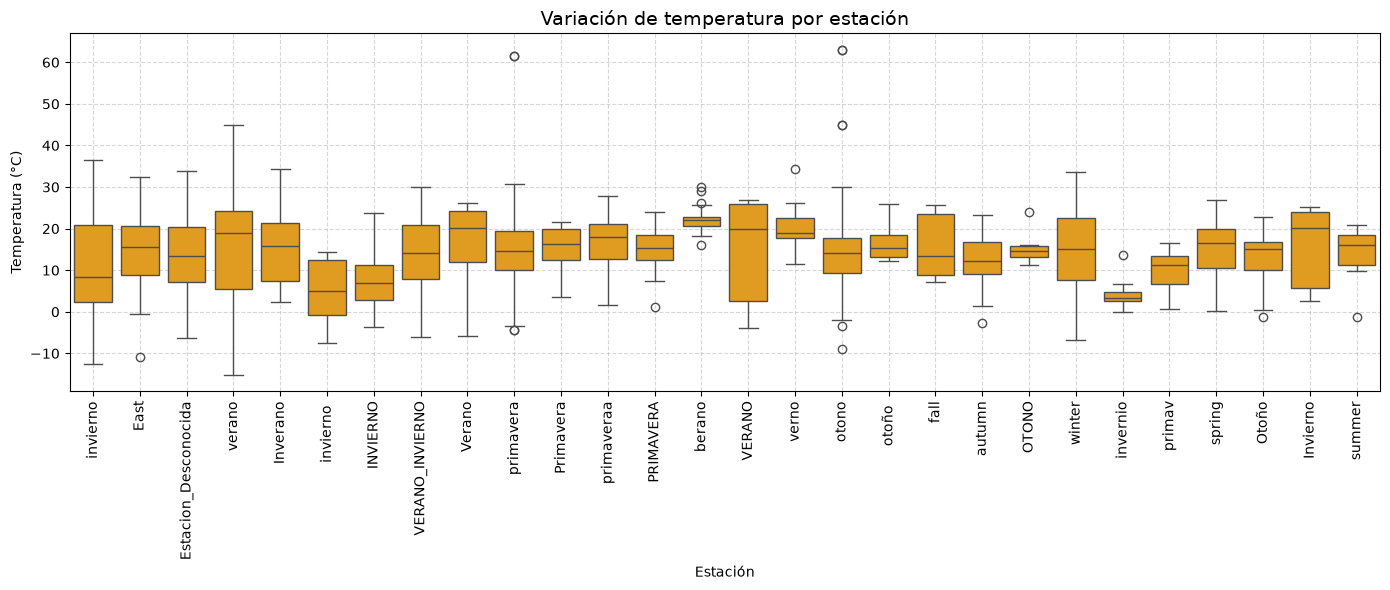

In [21]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    x=data['estacion_anio'],
    y=data['temp_max_manana'],
    color='orange'
)

plt.title('Variación de temperatura por estación', fontsize=14)
plt.xlabel('Estación')
plt.ylabel('Temperatura (°C)')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Distribución de la temperatura máxima mañana

Observamos cómo se comporta la variable objetivo que es la temperatura máxima del día siguiente.

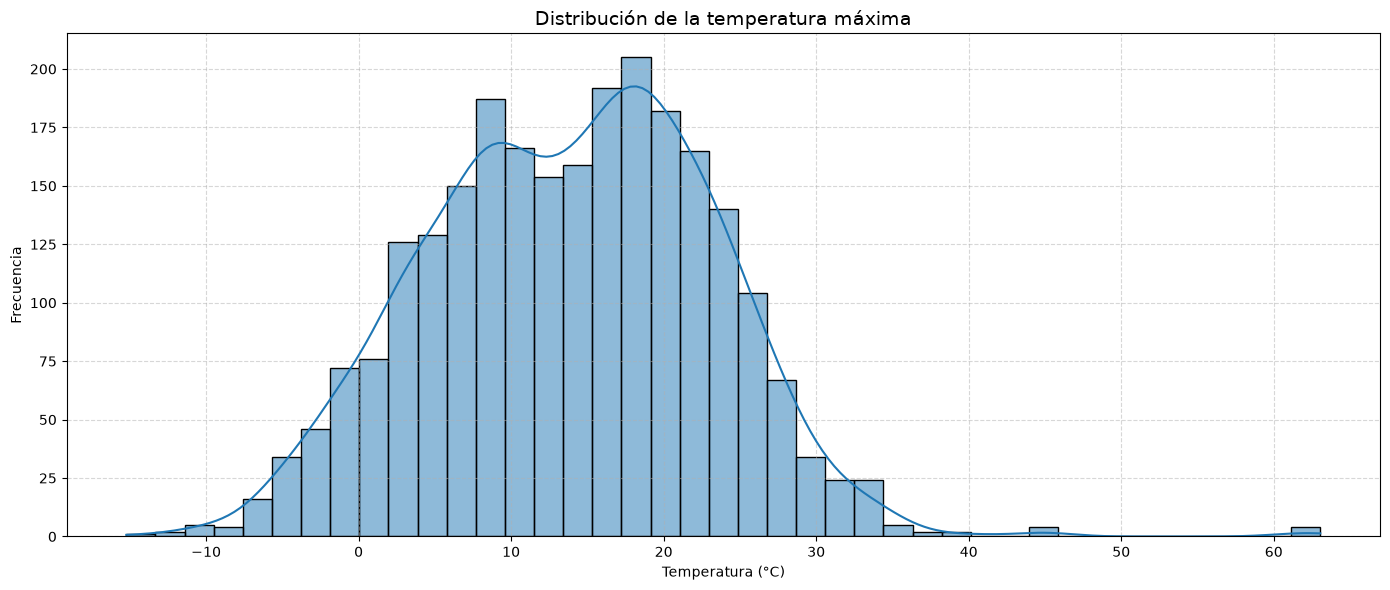

In [22]:
plt.figure(figsize=(14, 6))

sns.histplot(
    data['temp_max_manana'],
    kde=True
)

plt.title('Distribución de la temperatura máxima', fontsize=14)
plt.xlabel('Temperatura (°C)')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 1.6 Hallazgos de la exploración

#### Observaciones:

- sector_viento y estacion_anio no cumplen con las categorias, no son consistentes.
- La cantidad de valores nulos por categoria es relativamente bajo: menor a 3,7% en todos los casos.

#### Valores imposibles detectados:

- Valor de humedad mínima mayor a 100%.
- El max de registros_del_dia supera el máximo permitido de 144, pues es 287.
- Ráfaga de viento de -10000 m/s.
- rafaga_desv tiene valores negativos, imposible para una desviación estándar.
- Temperatura máxima de 63° C. La temperatura más alta registrada en Jena corrsponde a aproximadamente 40° C.
- rafaga_media con valores negativos.
- Algunos valores de humedad_media y humedad_min están guardados como fracción en lugar de porcentaje, por ejemplo: 0.91 en vez de 91.
- Valores como 9939.9 (presion_media) parecen tener la coma decimal desplazada.
- Hay valores mínimos que parecen ser mayores a la media y al máximo.
- Hay valores de desviación que se salen del minimo y máximo, eso también es imposible.


#### Outliers extremos pero posibles:

- Valores muy bajos de humedad, podrían ser días extremadamente secos.
- Aunque la temperatura mínima de Jena en invierno es de aproximadamente -5°C, sería posible, en casos extremos, que la temperatura baje a -15°C.


#### Decisiones para la preparación:

- Eliminar duplicados.
- Ajustar columnas categóricas.
- Corregir errores de escala o unidades.
- Invertir mínimos y máximos cuando aplique.
- Tratar como NaN los valores que sigan siendo imposibles.
- Revisar las fechas y corregir las inconsistencias entre fecha, anio, mes y dia_del_anio.
- Imputar los valores nulos restantes usando interpolación temporal o la mediana por mes si es necesario.
- Eliminar las filas donde falte la temp_max_manana, que es es la variable objetivo.

#### Multicolinealidad detectada:

- presion_media, presion_min y presion_max presentan una correlación alta entre ellas.
- humedad_media, humedad_min y humedad_desv también están fuertemente correlacionadas.
- viento_media y viento_max presentan una correlación alta.

#### Correlaciones con temperatura máxima:

- Las variables más relacionadas con temp_max_manana son las de humedad, especialmente humedad_min, humedad_desv y humedad_media.
- Las demás variables numéricas presentan correlaciones más débiles con la temperatura máxima.

#### Correlaciones con temperatura máxima (categóricas):

- mes y estacion_anio son las variables categóricas más relacionadas con temp_max_manana, lo cual tiene sentido porque la temperatura cambia con la época del año.
- sector_viento presenta una relación muy baja con la temperatura máxima.



## 2. Preparación de datos

### 2.1 Eliminar duplicados
Se eliminan las filas duplicadas detectadas en la exploración.

In [23]:
data = data.drop_duplicates()

In [24]:
data1 = data.copy()
data1["fecha"] = pd.to_datetime(data1["fecha"], format='mixed')
data1

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.778600,0.050000,1.559641,0.5753,1.3783,0.25,2.255577,0.8488,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.419500,0.220000,3.870000,0.9168,2.2274,0.63,6.130000,1.2544,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.250900,0.120000,3.640000,0.7299,2.0651,0.38,4.880000,0.9330,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.720400,0.540000,2.454415,0.7023,3.5649,1.38,4.430375,1.1835,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.800300,1.000000,7.810000,1.9521,5.9400,2.13,10.880000,NaN,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2407,NaT,991.9774,989.70,994.19,1.4006,0.608340,0.390500,80.8,14.2611,1.847600,0.240000,NaN,0.9015,3.1481,NaN,6.440000,1.2568,0.6842,0.5186,37.1636,144.0,2015.0,217.0,Inverano,August,NE,34.41
2434,NaT,983.5712,980.65,989.33,2.4154,70.488800,44.410000,84.7,13.7964,1.543600,10.294322,0.236121,1.0316,3.0192,0.88,7.238972,2.0331,-0.7062,-0.7043,224.9255,144.0,2015.0,244.0,otono,september,SO,20.03
2464,NaT,1004.4446,1002.62,1006.43,1.2320,0.006877,0.447600,94.2,17.3187,1.892400,0.160000,2.305028,1.7750,3.0048,0.36,5.623408,2.6245,1.0049,1.3243,52.8086,144.0,2015.0,274.0,Otoño,October,NE,17.35
2529,NaT,1002.1970,999.08,1005.34,2.0512,78.005500,57.340000,93.7,10.8056,10.956240,2.628000,26.388000,1.6727,4.7458,1.56,10.570000,2.2509,-2.8320,-0.6315,192.5714,144.0,2015.0,339.0,summer,JANUARY,S,9.80


### 2.2 Manejo de columnas categóricas

In [25]:
data1['mes'] = data1['mes'].replace(
    ['january', 'January', 'JANUARY', 'enero', 'Jan', 'Enero'],
    'enero'
)

data1['mes'] = data1['mes'].replace(
    ['february', 'February', 'FEBRUARY', 'febrero', 'Feb'],
    'febrero'
)

data1['mes'] = data1['mes'].replace(
    ['march', 'March', 'MARCH', 'marzo', 'Mar'],
    'marzo'
)

data1['mes'] = data1['mes'].replace(
    ['april', 'April', 'APRIL', 'abril', 'Apr'],
    'abril'
)

data1['mes'] = data1['mes'].replace(
    ['may', 'May', 'MAY', 'mayo'],
    'mayo'
)

data1['mes'] = data1['mes'].replace(
    ['june', 'June', 'JUNE', 'junio', 'Jun'],
    'junio'
)

data1['mes'] = data1['mes'].replace(
    ['july', 'July', 'JULY', 'julio', 'Jul'],
    'julio'
)

data1['mes'] = data1['mes'].replace(
    ['august', 'August', 'AUGUST', 'agosto', 'Aug'],
    'agosto'
)

data1['mes'] = data1['mes'].replace(
    ['september', 'September', 'SEPTEMBER', 'septiembre', 'Sep', 'Sept'],
    'septiembre'
)

data1['mes'] = data1['mes'].replace(
    ['october', 'October', 'OCTOBER', 'octubre', 'Oct'],
    'octubre'
)

data1['mes'] = data1['mes'].replace(
    ['november', 'November', 'NOVEMBER', 'noviembre', 'Nov'],
    'noviembre'
)

data1['mes'] = data1['mes'].replace(
    ['december', 'December', 'DECEMBER', 'diciembre', 'Dec'],
    'diciembre'
)

data1['sector_viento'] = data1['sector_viento'].replace(
    ['N', 'North', 'NORTH', 'Norte'],
    'N'
)

data1['sector_viento'] = data1['sector_viento'].replace(
    ['NE', 'Noreste', 'NORTHEAST', 'ne'],
    'NE'
)

data1['sector_viento'] = data1['sector_viento'].replace(
    ['E', 'East', 'EAST', 'Este'],
    'E'
)

data1['sector_viento'] = data1['sector_viento'].replace(
    ['SE', 'Sureste', 'SOUTHEAST'],
    'SE'
)

data1['sector_viento'] = data1['sector_viento'].replace(
    ['S', 'South', 'Sur', 's', 'SOUTH'],
    'S'
)

data1['sector_viento'] = data1['sector_viento'].replace(
    ['SO', 'Suroeste', 'so', 'SOUTHWEST'],
    'SO'
)

data1['sector_viento'] = data1['sector_viento'].replace(
    ['O', 'Oeste', 'o', 'West', 'WEST'],
    'O'
)

data1['sector_viento'] = data1['sector_viento'].replace(
    ['NO', 'Noroeste', 'NORTHWEST', 'no'],
    'NO'
)

objetos = ['mes', 'sector_viento']

for i in objetos:
    print("Valores únicos en " + i + ":")
    print(data1[i].unique())
    print(f"Total de valores únicos: {data1[i].nunique()} \n\n")

Valores únicos en mes:
<StringArray>
[     'enero',      'julio',       'mayo',          nan,      'junio',
 'septiembre',      'abril',  'noviembre',    'octubre',    'febrero',
     'agosto',      'marzo',  'diciembre']
Length: 13, dtype: str
Total de valores únicos: 12 


Valores únicos en sector_viento:
<StringArray>
['S', 'NE', 'SO', 'N', 'SE', nan, 'O', 'E', 'NO']
Length: 9, dtype: str
Total de valores únicos: 8 




### 2.3 Escala y unidades

Al revisar los boxplots se encontraron dos problemas de escala. En humedad_media y humedad_min hay algunos valores que están guardados como fracción, por ejemplo 0.91, en vez de porcentaje (91).

En presion_media hay valores como 9939.9 que parecen tener la coma decimal corrida. Si se divide entre 10, los valores quedan dentro del rango de presion_min y presion_max.

In [26]:
for col in ['humedad_media', 'humedad_min']:
    print(col)
    print("Valores como fracción:", (data1[col] <= 1.5).sum())
    print("Valores como porcentaje:", (data1[col] > 1.5).sum())


display(data1.loc[
    data1['humedad_media'] <= 1.5,
    ['humedad_media', 'humedad_min', 'humedad_max']
].head())

humedad_media
Valores como fracción: 777
Valores como porcentaje: 1721
humedad_min
Valores como fracción: 625
Valores como porcentaje: 1867


,humedad_media,humedad_min,humedad_max
0,0.910860,0.875000,94.80
1,0.920868,86.600000,96.30
8,0.839762,0.928437,59.98
14,0.911028,0.730000,97.60
17,0.827548,67.980000,94.30


In [27]:
# humedad de fracción a porcentaje
for col in ['humedad_media', 'humedad_min']:
    fraccion = data1[col] <= 1.5
    print(col, "corregidos:", fraccion.sum())
    data1.loc[fraccion, col] = data1.loc[fraccion, col] * 100

# presion_media
presion_error = data1['presion_media'] > 1100
print("presion_media corregidos:", presion_error.sum())
data1.loc[presion_error, 'presion_media'] = data1.loc[presion_error, 'presion_media'] / 10

humedad_media corregidos: 777
humedad_min corregidos: 625
presion_media corregidos: 5


**¿Por qué el umbral `<= 1.5`?** Esta corrección afecta a **777 de 2576 filas (~30%)** en `humedad_media` y a
**625 filas (~24%)** en `humedad_min`, es una proporción alta, así que merece justificarse explícitamente y no
tratarse como un ajuste menor. El umbral se apoya en el propio rango físico de la variable: la humedad relativa
solo puede estar entre 0% y 100%, así que cualquier valor ≤ 1.5 **no puede ser un porcentaje real** (¿1.5% de
humedad relativa en Jena, Alemania? Es prácticamente imposible) y, en cambio, sí es consistente con una fracción
(0 a 1) mal guardada,de hecho, tras multiplicar por 100 estos valores caen dentro del mismo rango que el resto de
la columna (ver `humedad_min`/`humedad_max` en las filas de ejemplo de la celda anterior). Con ~30% de las filas
afectadas, esto sugiere que **dos procesos de carga distintos** guardaron la humedad en unidades distintas (fracción
vs. porcentaje), no que sean valores atípicos aislados, reforzando que corregir la escala es más apropiado que
eliminar esas filas.

### 2.4 Mínimos y máximos

In [28]:
var = ['presion', 'humedad', 'viento', 'rafaga']

print('filas con min > max')
for v in var:
    col_min, col_media, col_max = v + '_min', v + '_media', v + '_max'
    invertidos = data1[col_min] > data1[col_max]
    print(v, ": ", invertidos.sum())

print()
display(data1.loc[data1['presion_min'] > data1['presion_max'], ['presion_min', 'presion_media', 'presion_max']].head())

filas con min > max
presion :  121
humedad :  121
viento :  120
rafaga :  122



,presion_min,presion_media,presion_max
43,994.906458,989.2739,988.44
44,1003.735938,994.9869,989.00
56,997.729414,990.5860,985.86
70,998.971077,992.2961,987.30
73,1003.906077,994.9090,989.35


Para las filas donde el valor mínimo es mayor que la media o el máximo se van a invertir los valores, así la media queda dentro del rango.

In [29]:
print('filas con min > max')
for v in var:
    minimo = v + '_min'
    maximo = v + '_max'

    intercambio = data1[minimo] > data1[maximo]
    print(v, ":", intercambio.sum())

    temporal = data1.loc[intercambio, minimo].copy()
    data1.loc[intercambio, minimo] = data1.loc[intercambio, maximo]
    data1.loc[intercambio, maximo] = temporal

filas con min > max
presion : 121
humedad : 121
viento : 120
rafaga : 122


### 2.5 Valores imposibles restantes

Los valores físicamente imposibles después de las correcciones se marcan como NaN para tratarlos en la etapa de imputación:

- La media sigue fuera del minimo y maximo
- humedad_min que sea mayor a 100%
- registros_del_dia mayores a 144
- rafaga_media negativa, la ráfaga no puede ser negativa
- rafaga_min con magnitud extrema (ejemplo: -9999)
- viento_norte físicamente imposible
- viento_desv y rafaga_desv negativos, mayores a 50, o mayores al rango minimo y maximo
- temp_max_manana fuera del rango físicamente posible en Jena, Alemania

In [30]:
for v in var:
    minimo = v + '_min'
    media = v + '_media'
    maximo = v + '_max'

    error = (data1[media] < data1[minimo]) | (data1[media] > data1[maximo])
    print(media, "fuera de rango:", error.sum())
    data1.loc[error, media] = np.nan


# humedad mayor a 100%
for columna in ['humedad_min', 'humedad_max']:
    error = data1[columna] > 100
    print(columna, "mayor a 100%:", error.sum())
    data1.loc[error, columna] = np.nan


# registros del día
error = data1['registros_del_dia'] > 144
print("registros_del_dia mayores a 144:", error.sum())
data1.loc[error, 'registros_del_dia'] = np.nan


# ráfaga media negativa
error = data1['rafaga_media'] < 0
print("rafaga_media negativas:", error.sum())
data1.loc[error, 'rafaga_media'] = np.nan


# ráfaga mínima demasiado baja
error = data1['rafaga_min'] < -50
print("rafaga_min menores a -50:", error.sum())
data1.loc[error, 'rafaga_min'] = np.nan


# viento norte fuera de rango
error = data1['viento_norte'].abs() > 30
print("viento_norte fuera de rango:", error.sum())
data1.loc[error, 'viento_norte'] = np.nan


# revisar las desviaciones
for nombre in ['viento', 'rafaga']:
    desviacion = nombre + '_desv'
    minimo = nombre + '_min'
    maximo = nombre + '_max'

    error = (
        (data1[desviacion] < 0) |
        (data1[desviacion] > 50) |
        (data1[desviacion] > data1[maximo] - data1[minimo])
    )

    print(desviacion, "fuera de rango:", error.sum())
    data1.loc[error, desviacion] = np.nan


# temperatura máxima fuera de rango
error = (data1['temp_max_manana'] > 45) | (data1['temp_max_manana'] < -30)
print("temp_max_manana fuera de rango:", error.sum())
data1.loc[error, 'temp_max_manana'] = np.nan

presion_media fuera de rango: 8
humedad_media fuera de rango: 35
viento_media fuera de rango: 47
rafaga_media fuera de rango: 22
humedad_min mayor a 100%: 1
humedad_max mayor a 100%: 27
registros_del_dia mayores a 144: 4
rafaga_media negativas: 1
rafaga_min menores a -50: 1
viento_norte fuera de rango: 1
viento_desv fuera de rango: 257
rafaga_desv fuera de rango: 255
temp_max_manana fuera de rango: 3


**¿Por qué marcar como NaN cuando `desv > max - min`?** Esta regla afecta a **257 filas de `viento_desv`
(~10%)** y **255 filas de `rafaga_desv` (~10%)**. La justificación es puramente matemática, no un juicio subjetivo:
la desviación estándar de un conjunto de valores acotado entre un mínimo y un máximo **no puede exceder el rango**
(`máximo − mínimo`) de esos mismos valores, es una propiedad de la definición de desviación estándar, sin
excepciones. Un valor que la viola no es un dato extremo pero válido, es matemáticamente imposible dado el resto de
la fila, así que no tiene sentido "salvarlo" con una transformación de escala (como sí se hizo con la humedad o la
presión); la única opción consistente es tratarlo como dato faltante y dejar que la imputación de 2.7 (interpolación
temporal) lo reconstruya a partir de días cercanos.

### 2.6 Reconstrucción de fecha

Primero verificamos cómo se encuentran los datos luego de haber corregido las categorias:

In [31]:
meses_nombre = {
    1: 'enero', 2: 'febrero', 3: 'marzo', 4: 'abril',
    5: 'mayo', 6: 'junio', 7: 'julio', 8: 'agosto',
    9: 'septiembre', 10: 'octubre', 11: 'noviembre', 12: 'diciembre'
}

error_anio = data1['anio'].astype('Int64') != data1['fecha'].dt.year
error_dia = data1['dia_del_anio'].astype('Int64') != data1['fecha'].dt.dayofyear
error_mes = data1['mes'].str.lower() != data1['fecha'].dt.month.map(meses_nombre)

print("Errores en año:", error_anio.sum())
print("Errores en día:", error_dia.sum())
print("Errores en mes:", error_mes.sum())

errores = pd.DataFrame({
    'anio': error_anio,
    'mes': error_mes,
    'dia': error_dia
})

filas_error = errores.any(axis=1)

display(data1.loc[filas_error, ['fecha', 'anio', 'mes', 'dia_del_anio']])

Errores en año: 0
Errores en día: 0
Errores en mes: 1291


,fecha,anio,mes,dia_del_anio
1,2009-01-02,2009.0,julio,2.0
7,2009-01-08,2009.0,mayo,8.0
9,2009-01-10,2009.0,NaN,10.0
11,2009-01-12,2009.0,junio,12.0
14,2009-01-15,2009.0,septiembre,15.0
...,...,...,...,...
2407,NaT,2015.0,agosto,217.0
2434,NaT,2015.0,septiembre,244.0
2464,NaT,2015.0,octubre,274.0
2529,NaT,2015.0,enero,339.0


Se presentan 1291 inconsistencias. Entonces vamos a tomar fecha como referencia para completar y corregir las variables.

In [32]:
# fecha cuando anio y dia_del_anio están disponibles
faltan_fecha = data1['fecha'].isna() & data1['anio'].notna() & data1['dia_del_anio'].notna()

data1.loc[faltan_fecha, 'fecha'] = (
    pd.to_datetime(
        data1.loc[faltan_fecha, 'anio'].astype('Int64').astype(int).astype(str),
        format='%Y'
    )
    + pd.to_timedelta(
        data1.loc[faltan_fecha, 'dia_del_anio'].astype('Int64').astype(int) - 1,
        unit='D'
    )
)

print("Filas con fecha:", data1['fecha'].notna().sum())
print("Filas sin fecha:", data1['fecha'].isna().sum())

# Completar anio y dia_del_anio usando la fecha
faltan_anio = data1['anio'].isna() & data1['fecha'].notna()
data1.loc[faltan_anio, 'anio'] = data1.loc[faltan_anio, 'fecha'].dt.year

faltan_dia = data1['dia_del_anio'].isna() & data1['fecha'].notna()
data1.loc[faltan_dia, 'dia_del_anio'] = data1.loc[faltan_dia, 'fecha'].dt.dayofyear

Filas con fecha: 2568
Filas sin fecha: 4


In [33]:
# mes a partir de la fecha
data1['mes'] = data1['fecha'].dt.month.map(meses_nombre)

mapeo_estacion = {
    'diciembre': 'invierno', 'enero': 'invierno', 'febrero': 'invierno',
    'marzo': 'primavera', 'abril': 'primavera', 'mayo': 'primavera',
    'junio': 'verano', 'julio': 'verano', 'agosto': 'verano',
    'septiembre': 'otono', 'octubre': 'otono', 'noviembre': 'otono'
}

# estación a partir del mes
data1['estacion_anio'] = data1['mes'].map(mapeo_estacion)

Se verifica que mes ya no tenga inconsistencias con la fecha.

In [34]:
error_mes = (
    data1['mes'].str.lower() != data1['fecha'].dt.month.map(meses_nombre)
)

print("Inconsistencias entre mes y fecha:", error_mes.sum())

data1[['fecha', 'anio', 'dia_del_anio', 'mes', 'estacion_anio']].isna().sum()

Inconsistencias entre mes y fecha: 4


fecha            4
anio             3
dia_del_anio     1
mes              4
estacion_anio    4
dtype: int64

### 2.7 Imputación de valores faltantes

Hasta ahora los valores nulos solo se habían contado, pero no se habían rellenado ni eliminado. Como los datos están ordenados por fecha utilizaremos los valores de los días cercanos para completar los datos faltantes.

- se eliminan filas sin fecha y sin temp_max_manana
- interpolar para rellenar
- moda para sector viento

In [35]:
# Eliminar filas sin fecha o sin temp
antes = len(data1)

data1 = data1[data1['fecha'].notna()].copy()
print("Filas sin fecha eliminadas:", antes - len(data1))

antes = len(data1)

data1 = data1[data1['temp_max_manana'].notna()].copy()
print("Filas sin temp_max_manana eliminadas:", antes - len(data1))

# Ordenar por fecha
data1 = data1.sort_values('fecha').reset_index(drop=True)

Filas sin fecha eliminadas: 4
Filas sin temp_max_manana eliminadas: 98


In [36]:
columnas = cuantitativas_continuas + ['registros_del_dia']

nulos_antes = data1[columnas].isna().sum().sum()

data1[columnas] = data1[columnas].interpolate(
    method='linear',
    limit_direction='both'
)

# Completar los que todavía tengan nan usando la mediana del mes
for columna in columnas:
    data1[columna] = data1[columna].fillna(
        data1.groupby('mes')[columna].transform('median')
    )

data1['registros_del_dia'] = data1['registros_del_dia'].round()

print("Nulos numéricos: \n", nulos_antes, "antes\n",
      data1[columnas].isna().sum().sum(), "después")

Nulos numéricos: 
 2100 antes
 0 después


### 2.8 Análisis de correlación y multicolinealidad

El heatmap de la sección 1.5 se calculó sobre los datos originales, sin limpiar, así que estaba distorsionado por los valores imposibles (por ejemplo, el error de coma decimal en `presion_media` que llegaba a 9939). Ahora que `data1` está limpio e imputado, se recalcula la correlación para que sea representativa.

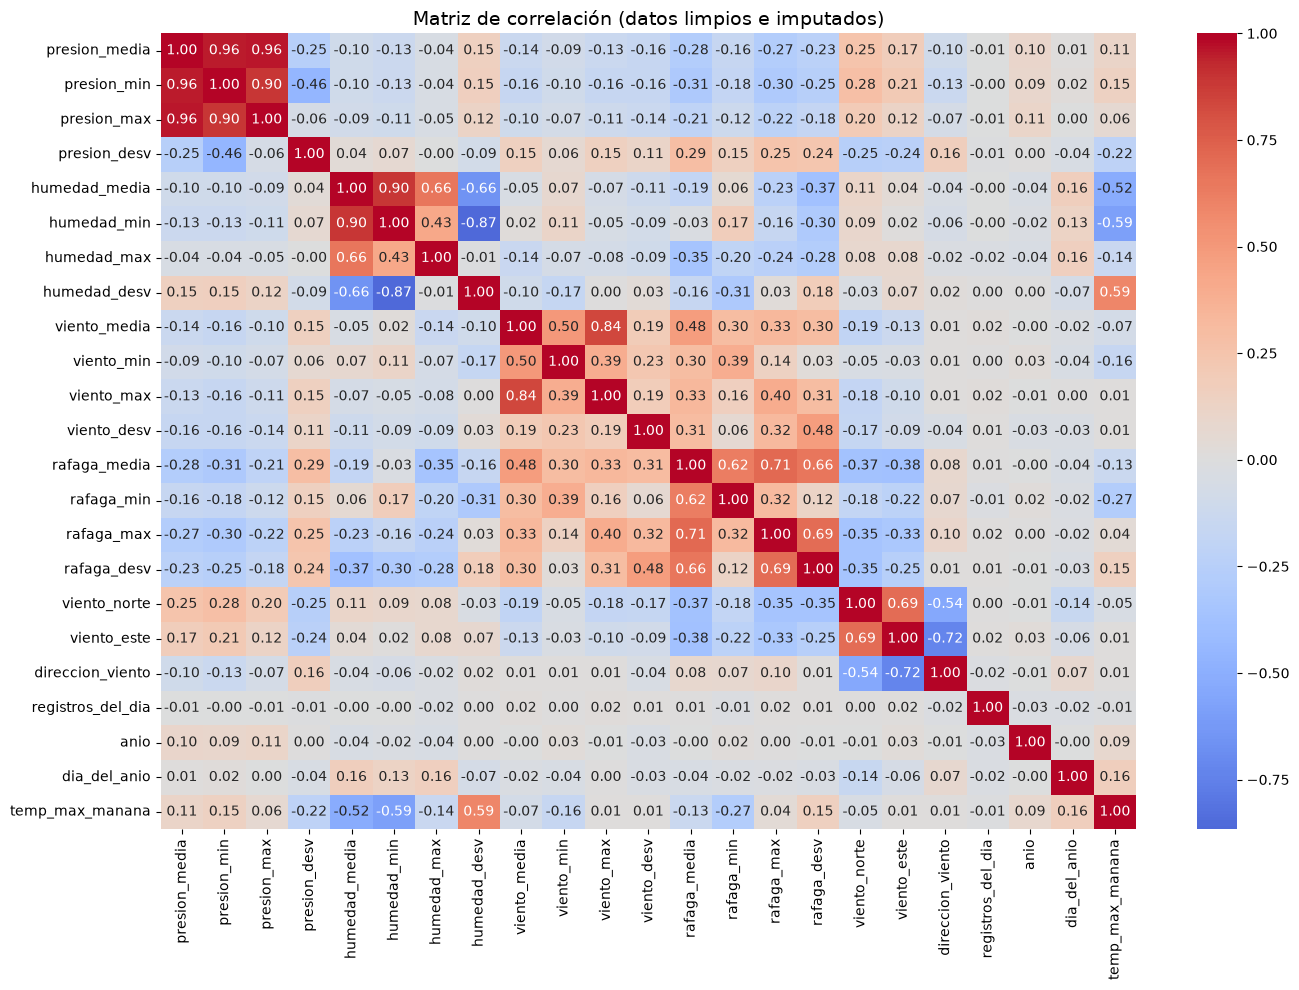

In [37]:
numeric_cols_data1 = data1.select_dtypes(include=['float64', 'int64']).columns
corr_data1 = data1[numeric_cols_data1].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_data1, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de correlación (datos limpios e imputados)', fontsize=14)
plt.tight_layout()
plt.show()

**Correlación de cada variable numérica con `temp_max_manana`**, ordenada por fuerza de asociación:

In [38]:
corr_con_target = (
    corr_data1['temp_max_manana']
    .drop('temp_max_manana')
    .sort_values(key=lambda x: x.abs(), ascending=False)
)
display(corr_con_target)

humedad_min         -0.586339
humedad_desv         0.585307
humedad_media       -0.519746
rafaga_min          -0.273670
presion_desv        -0.215772
dia_del_anio         0.163022
viento_min          -0.161747
rafaga_desv          0.152395
presion_min          0.146789
humedad_max         -0.140081
rafaga_media        -0.130395
presion_media        0.113093
anio                 0.086424
viento_media        -0.072597
presion_max          0.059969
viento_norte        -0.046482
rafaga_max           0.038116
viento_desv          0.013060
direccion_viento     0.011387
viento_max           0.011277
viento_este          0.009944
registros_del_dia   -0.007304
Name: temp_max_manana, dtype: float64

**Pares de variables predictoras con correlación fuerte entre sí** (|r| > 0.8): son candidatas a multicolinealidad, y para el modelo de regresión conviene dejar solo una de cada par/grupo.

In [39]:
predictoras = [c for c in numeric_cols_data1 if c != 'temp_max_manana']

pares_colineales = []
for i, c1 in enumerate(predictoras):
    for c2 in predictoras[i + 1:]:
        r = corr_data1.loc[c1, c2]
        if abs(r) > 0.8:
            pares_colineales.append((c1, c2, round(r, 3)))

pd.DataFrame(pares_colineales, columns=['variable_1', 'variable_2', 'correlacion']).sort_values(
    'correlacion', key=lambda x: x.abs(), ascending=False
)

,variable_1,variable_2,correlacion
1,presion_media,presion_max,0.963
0,presion_media,presion_min,0.956
2,presion_min,presion_max,0.898
3,humedad_media,humedad_min,0.896
4,humedad_min,humedad_desv,-0.867
5,viento_media,viento_max,0.838


**Asociación de las variables categóricas con `temp_max_manana`**: como no son numéricas, no se puede calcular un coeficiente de correlación de Pearson directamente. En su lugar se usa `eta cuadrado` (qué proporción de la varianza de la temperatura queda explicada por la categoría) y se muestra la temperatura media por categoría.

In [40]:
def eta_cuadrado(df, columna_categorica, columna_numerica):
    media_general = df[columna_numerica].mean()
    ss_entre = df.groupby(columna_categorica)[columna_numerica].apply(
        lambda x: len(x) * (x.mean() - media_general) ** 2
    ).sum()
    ss_total = ((df[columna_numerica] - media_general) ** 2).sum()
    return ss_entre / ss_total

for col in ['estacion_anio', 'mes', 'sector_viento']:
    print(f"{col}: eta² = {eta_cuadrado(data1, col, 'temp_max_manana'):.4f}")
    print(data1.groupby(col)['temp_max_manana'].mean().sort_values(ascending=False))
    print()

estacion_anio: eta² = 0.5659
estacion_anio
verano       23.222763
primavera    14.218458
otono        13.700112
invierno      3.878963
Name: temp_max_manana, dtype: float64

mes: eta² = 0.6646
mes
julio         24.617255
agosto        23.718685
junio         21.291535
septiembre    18.741650
mayo          18.042021
abril         15.325882
octubre       13.583105
marzo          9.293189
noviembre      8.829552
diciembre      4.875075
febrero        3.946502
enero          2.781874
Name: temp_max_manana, dtype: float64

sector_viento: eta² = 0.0247
sector_viento
E     19.721111
SE    17.771471
SO    14.314553
NE    13.317684
O     13.247210
S     13.196323
NO    12.515385
N     12.011600
Name: temp_max_manana, dtype: float64



**Conclusiones para la construcción del modelo (sección 3):**

- Las variables más correlacionadas con `temp_max_manana` son las de humedad (`humedad_min`, `humedad_desv`, `humedad_media`); el resto de variables numéricas tiene correlaciones débiles (|r| < 0.3).
- `mes` y `estacion_anio` son las variables categóricas más asociadas con la temperatura (eta² alto): tiene sentido, por el ciclo estacional. `sector_viento` aporta poco.
- Hay multicolinealidad clara entre `presion_media`/`presion_min`/`presion_max`, entre `humedad_media`/`humedad_min`/`humedad_desv`, y entre `viento_media`/`viento_max`. Para el modelo conviene dejar un solo representante de cada grupo en vez de meter las tres variables casi redundantes.

### 2.9 Función de preparación reutilizable

Los pasos 2.1 a 2.7 se aplicaron a mano sobre `data1` para poder revisar cada decisión con detalle. Ahora se empaqueta esa misma lógica en una función, `preparar_datos()`, para poder aplicarla sobre los datos de prueba sin etiquetar (sección 7) sin copiar todo el código otra vez. Se verifica que, aplicada sobre los datos originales, reproduce el mismo `data1` que se construyó a mano.

In [41]:
mapa_mes = {}
for valores, canon in [
    (['january', 'January', 'JANUARY', 'enero', 'Jan', 'Enero'], 'enero'),
    (['february', 'February', 'FEBRUARY', 'febrero', 'Feb'], 'febrero'),
    (['march', 'March', 'MARCH', 'marzo', 'Mar'], 'marzo'),
    (['april', 'April', 'APRIL', 'abril', 'Apr'], 'abril'),
    (['may', 'May', 'MAY', 'mayo'], 'mayo'),
    (['june', 'June', 'JUNE', 'junio', 'Jun'], 'junio'),
    (['july', 'July', 'JULY', 'julio', 'Jul'], 'julio'),
    (['august', 'August', 'AUGUST', 'agosto', 'Aug'], 'agosto'),
    (['september', 'September', 'SEPTEMBER', 'septiembre', 'Sep', 'Sept'], 'septiembre'),
    (['october', 'October', 'OCTOBER', 'octubre', 'Oct'], 'octubre'),
    (['november', 'November', 'NOVEMBER', 'noviembre', 'Nov'], 'noviembre'),
    (['december', 'December', 'DECEMBER', 'diciembre', 'Dec'], 'diciembre'),
]:
    for valor in valores:
        mapa_mes[valor] = canon

mapa_sector_viento = {}
for valores, canon in [
    (['N', 'North', 'NORTH', 'Norte'], 'N'),
    (['NE', 'Noreste', 'NORTHEAST', 'ne'], 'NE'),
    (['E', 'East', 'EAST', 'Este'], 'E'),
    (['SE', 'Sureste', 'SOUTHEAST'], 'SE'),
    (['S', 'South', 'Sur', 's', 'SOUTH'], 'S'),
    (['SO', 'Suroeste', 'so', 'SOUTHWEST'], 'SO'),
    (['O', 'Oeste', 'o', 'West', 'WEST'], 'O'),
    (['NO', 'Noroeste', 'NORTHWEST', 'no'], 'NO'),
]:
    for valor in valores:
        mapa_sector_viento[valor] = canon


def preparar_datos(df_raw, mediana_referencia=None, quitar_duplicados=True,
                    eliminar_incompletos=True, mantener_orden_original=False, imputar=True):
    """Aplica sobre df_raw los mismos pasos usados manualmente en las secciones 2.1 a 2.7."""
    df = df_raw.copy()
    df['fecha'] = pd.to_datetime(df['fecha'], format='mixed')
    # Se ordena por fecha ANTES de quitar duplicados (igual que en 2.1, celda de sort antes del drop_duplicates)
    # para que el desempate de fechas repetidas sea identico al del proceso manual: si dos filas comparten
    # la misma fecha, su orden relativo (y por lo tanto el resultado de interpolate(), que depende de la
    # posicion) debe quedar igual en ambos caminos.
    df = df.sort_values('fecha', na_position='last')

    if quitar_duplicados:
        df = df.drop_duplicates()

    # 2.2 columnas categoricas
    df['mes'] = df['mes'].replace(mapa_mes)
    df['sector_viento'] = df['sector_viento'].replace(mapa_sector_viento)

    # 2.3 escala y unidades
    for col in ['humedad_media', 'humedad_min']:
        fraccion = df[col] <= 1.5
        df.loc[fraccion, col] = df.loc[fraccion, col] * 100

    presion_error = df['presion_media'] > 1100
    df.loc[presion_error, 'presion_media'] = df.loc[presion_error, 'presion_media'] / 10

    # 2.4 minimos y maximos invertidos
    for v in var:
        col_min, col_max = v + '_min', v + '_max'
        intercambio = df[col_min] > df[col_max]
        temporal = df.loc[intercambio, col_min].copy()
        df.loc[intercambio, col_min] = df.loc[intercambio, col_max]
        df.loc[intercambio, col_max] = temporal

    # 2.5 valores imposibles restantes -> NaN
    for v in var:
        minimo, media, maximo = v + '_min', v + '_media', v + '_max'
        error = (df[media] < df[minimo]) | (df[media] > df[maximo])
        df.loc[error, media] = np.nan

    for columna in ['humedad_min', 'humedad_max']:
        df.loc[df[columna] > 100, columna] = np.nan

    df.loc[df['registros_del_dia'] > 144, 'registros_del_dia'] = np.nan
    df.loc[df['rafaga_media'] < 0, 'rafaga_media'] = np.nan
    df.loc[df['rafaga_min'] < -50, 'rafaga_min'] = np.nan
    df.loc[df['viento_norte'].abs() > 30, 'viento_norte'] = np.nan

    for nombre in ['viento', 'rafaga']:
        desviacion, minimo, maximo = nombre + '_desv', nombre + '_min', nombre + '_max'
        error = (
            (df[desviacion] < 0) |
            (df[desviacion] > 50) |
            (df[desviacion] > df[maximo] - df[minimo])
        )
        df.loc[error, desviacion] = np.nan

    if 'temp_max_manana' in df.columns:
        error = (df['temp_max_manana'] > 45) | (df['temp_max_manana'] < -30)
        df.loc[error, 'temp_max_manana'] = np.nan

    # 2.6 reconstruccion de fecha / anio / dia_del_anio / mes / estacion_anio
    faltan_fecha = df['fecha'].isna() & df['anio'].notna() & df['dia_del_anio'].notna()
    df.loc[faltan_fecha, 'fecha'] = (
        pd.to_datetime(df.loc[faltan_fecha, 'anio'].astype('Int64').astype(int).astype(str), format='%Y')
        + pd.to_timedelta(df.loc[faltan_fecha, 'dia_del_anio'].astype('Int64').astype(int) - 1, unit='D')
    )

    faltan_anio = df['anio'].isna() & df['fecha'].notna()
    df.loc[faltan_anio, 'anio'] = df.loc[faltan_anio, 'fecha'].dt.year

    faltan_dia = df['dia_del_anio'].isna() & df['fecha'].notna()
    df.loc[faltan_dia, 'dia_del_anio'] = df.loc[faltan_dia, 'fecha'].dt.dayofyear

    df['mes'] = df['fecha'].dt.month.map(meses_nombre)
    df['estacion_anio'] = df['mes'].map(mapeo_estacion)

    # eliminar filas sin fecha o sin variable objetivo (solo aplica si eliminar_incompletos=True)
    if eliminar_incompletos:
        df = df[df['fecha'].notna()].copy()
        if 'temp_max_manana' in df.columns:
            df = df[df['temp_max_manana'].notna()].copy()

    df = df.sort_values('fecha')

    # 2.7 imputacion (opcional: imputar=False deja los NaN, para poder particionar ANTES de imputar y evitar fuga)
    columnas_interp = [c for c in (cuantitativas_continuas + ['registros_del_dia']) if c in df.columns]
    if imputar:
        df[columnas_interp] = df[columnas_interp].interpolate(method='linear', limit_direction='both')

        if mediana_referencia is None:
            for columna in columnas_interp:
                df[columna] = df[columna].fillna(df.groupby('mes')[columna].transform('median'))
        else:
            for columna in columnas_interp:
                faltantes = df[columna].isna()
                if faltantes.any():
                    df.loc[faltantes, columna] = df.loc[faltantes, 'mes'].map(mediana_referencia[columna])
                    df[columna] = df[columna].fillna(mediana_referencia[columna].median())

        df['registros_del_dia'] = df['registros_del_dia'].round()

    if mantener_orden_original:
        df = df.sort_index()
    else:
        df = df.reset_index(drop=True)

    return df


# Verificacion: aplicar la funcion sobre los datos originales debe reproducir data1
data1_funcion = preparar_datos(datos_meteorologicos)

print("Filas data1 (manual):", data1.shape, " | Filas data1_funcion (funcion):", data1_funcion.shape)
print("Mismas columnas:", list(data1.columns) == list(data1_funcion.columns))

comparables = data1.reset_index(drop=True)
comparables_fn = data1_funcion.reset_index(drop=True)
cols_numericas_check = cuantitativas_continuas + ['registros_del_dia']
diferencia_maxima = (comparables[cols_numericas_check] - comparables_fn[cols_numericas_check]).abs().max().max()
print("Maxima diferencia numerica entre data1 manual y data1_funcion:", diferencia_maxima)
assert diferencia_maxima < 1e-6, "La funcion no esta reproduciendo data1 exactamente"

# medianas de referencia por mes (calculadas SOLO con el train limpio), para imputar datos futuros/prueba sin fuga de informacion
medianas_referencia_datos_etiquetados = data1.groupby('mes')[cuantitativas_continuas + ['registros_del_dia']].median()

Filas data1 (manual): (2470, 27)  | Filas data1_funcion (funcion): (2470, 27)
Mismas columnas: True
Maxima diferencia numerica entre data1 manual y data1_funcion: 0.0


## 3. Construcción de un modelo de regresión lineal

Se sigue lo indicado en el enunciado: partición entrenamiento/prueba con `random_state=42` y `test_size=0.25`. Esta partición de prueba es interna, un subconjunto de `DatosLab1.csv` que sí tiene la etiqueta `temp_max_manana`. Es distinta del archivo `DatosTestLab1.csv` (sección 7), que no tiene etiqueta y sobre el cual se van a generar las predicciones finales a entregar.

Para evitar fuga de información se cuidaron dos cosas. Primero, dentro de cada `Pipeline` de scikit-learn el escalado y la codificación de categóricas se ajustan (`fit`) únicamente con los datos de entrenamiento. Segundo, a diferencia de `data1` (que se imputó sobre el conjunto completo en la sección 2.7, antes de particionar), aquí la partición se hace antes de imputar los valores faltantes, y cada partición se imputa solo con sus propios vecinos temporales. Si no se hiciera así, la interpolación de una fila de entrenamiento podría terminar usando como vecino una fila que quedó en el conjunto de prueba, o al revés. El detalle de esta partición está en la celda de código de abajo.

Se construyen tres modelos de regresión lineal con estrategias de preparación de datos distintas, cada uno como un `Pipeline` de scikit-learn (preprocesamiento + modelo):

- Modelo 1, base: todas las variables numéricas de `data1` y las tres categóricas (`mes`, `estacion_anio`, `sector_viento`), sin tratar la multicolinealidad detectada en 2.8. Sirve de referencia para ver qué pasa si no se trata la colinealidad (de hecho `estacion_anio` se deriva directamente de `mes`, así que hay colinealidad perfecta entre las dos).
- Modelo 2, selección informada: se seleccionan variables numéricas de forma programática, reutilizando `corr_con_target` y `corr_data1` de la sección 2.8. Se recorren las variables candidatas (|correlación con el objetivo| > 0.10) de mayor a menor correlación y se descarta una si tiene |correlación| > 0.80 con alguna ya seleccionada. Como categórica solo se usa `mes` (se descarta `estacion_anio` por ser redundante con `mes`, y `sector_viento` por su bajo η² con el objetivo).
- Modelo 3, estacionalidad cíclica más regularización: usa las mismas variables numéricas del modelo 2, pero cambia las categóricas de fecha por una codificación cíclica de `dia_del_anio` (seno y coseno, para que el 31 de diciembre y el 1 de enero queden cerca en vez de saltar de 366 a 1) y usa `RidgeCV` en vez de eliminar manualmente más columnas.

In [42]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

TARGET = 'temp_max_manana'


def agregar_ciclicas(df):
    df = df.copy()
    df['sin_dia_anio'] = np.sin(2 * np.pi * df['dia_del_anio'] / 365.25)
    df['cos_dia_anio'] = np.cos(2 * np.pi * df['dia_del_anio'] / 365.25)
    return df


# --- Particion SIN fuga de informacion ---
# data1 fue imputado (interpolacion + mediana por mes) sobre TODO el conjunto, antes de cualquier
# particion (seccion 2.7). Para evaluar el modelo de forma honesta, se repite la preparacion con
# preparar_datos(imputar=False) para tener las mismas filas SIN los valores rellenados, se hace la
# particion sobre esas filas, y se imputa cada particion usando UNICAMENTE sus propios vecinos
# temporales (nunca datos de la otra particion).
data1_sin_imputar = preparar_datos(datos_meteorologicos, imputar=False)
assert (data1_sin_imputar['fecha'].values == data1.reset_index(drop=True)['fecha'].values).all(), \
    "data1_sin_imputar debe tener las mismas filas, en el mismo orden, que data1"

idx_train, idx_test = train_test_split(data1_sin_imputar.index, test_size=0.25, random_state=42)

columnas_interp = [c for c in cuantitativas_continuas + ['registros_del_dia'] if c in data1_sin_imputar.columns]


def imputar_particion(df_particion, columnas):
    df_particion = df_particion.sort_values('fecha').copy()
    df_particion[columnas] = df_particion[columnas].interpolate(method='linear', limit_direction='both')
    for columna in columnas:
        df_particion[columna] = df_particion[columna].fillna(
            df_particion.groupby('mes')[columna].transform('median')
        )
    df_particion['registros_del_dia'] = df_particion['registros_del_dia'].round()
    return df_particion.sort_index()


data_train = agregar_ciclicas(imputar_particion(data1_sin_imputar.loc[idx_train], columnas_interp))
data_test = agregar_ciclicas(imputar_particion(data1_sin_imputar.loc[idx_test], columnas_interp))

X_train = data_train.drop(columns=[TARGET, 'fecha'])
y_train = data_train[TARGET]
X_test = data_test.drop(columns=[TARGET, 'fecha'])
y_test = data_test[TARGET]

print("X_train:", X_train.shape, " X_test:", X_test.shape)

diff_train = (data_train[columnas_interp] - data1.reset_index(drop=True).loc[idx_train, columnas_interp]).abs()
diff_test = (data_test[columnas_interp] - data1.reset_index(drop=True).loc[idx_test, columnas_interp]).abs()
celdas_afectadas = (diff_train > 1e-9).sum().sum() + (diff_test > 1e-9).sum().sum()
total_celdas = data_train[columnas_interp].size + data_test[columnas_interp].size
print(f"Celdas cuyo valor imputado cambio al evitar la fuga entre particiones: {celdas_afectadas} de {total_celdas} "
      f"({celdas_afectadas / total_celdas:.2%})")

# --- Datos completos para el modelo final de produccion (seccion 7) ---

data_modelo = agregar_ciclicas(data1.copy())
X = data_modelo.drop(columns=[TARGET, 'fecha'])
y = data_modelo[TARGET]

cv = KFold(n_splits=5, shuffle=True, random_state=42)


def rmse_cv(pipeline, X_tr, y_tr):
    scores = cross_val_score(pipeline, X_tr, y_tr, cv=cv, scoring='neg_root_mean_squared_error')
    return -scores.mean(), scores.std()

X_train: (1852, 27)  X_test: (618, 27)
Celdas cuyo valor imputado cambio al evitar la fuga entre particiones: 1140 de 49400 (2.31%)


### 3.1 Modelo 1: base, todas las variables sin tratar colinealidad

In [43]:
categoricas_m1 = ['mes', 'estacion_anio', 'sector_viento']
numericas_m1 = [c for c in predictoras if c in X.columns]

preprocesamiento_m1 = ColumnTransformer([
    ('num', StandardScaler(), numericas_m1),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categoricas_m1),
])

modelo1 = Pipeline([
    ('prep', preprocesamiento_m1),
    ('reg', LinearRegression()),
])

rmse1_media, rmse1_std = rmse_cv(modelo1, X_train, y_train)
print(f"Modelo 1 - RMSE promedio (CV 5-fold, train): {rmse1_media:.3f} +/- {rmse1_std:.3f}")
print(f"Variables numericas: {len(numericas_m1)} | categoricas: {categoricas_m1}")

Modelo 1 - RMSE promedio (CV 5-fold, train): 4.642 +/- 0.471
Variables numericas: 22 | categoricas: ['mes', 'estacion_anio', 'sector_viento']


### 3.2 Modelo 2: selección informada, sin colinealidad

Se aplica el criterio descrito arriba usando `corr_con_target` (ya ordenada por |correlación| descendente) y `corr_data1`.

In [44]:
umbral_corr_objetivo = 0.10
umbral_colinealidad = 0.80

candidatas = corr_con_target[corr_con_target.abs() > umbral_corr_objetivo].index.tolist()

seleccionadas_m2 = []
for var_candidata in candidatas:  # ya viene ordenada por |correlacion| descendente
    colineal = any(
        abs(corr_data1.loc[var_candidata, ya_elegida]) > umbral_colinealidad
        for ya_elegida in seleccionadas_m2
    )
    if not colineal:
        seleccionadas_m2.append(var_candidata)

print(f"Variables candidatas (|r| > {umbral_corr_objetivo}): {len(candidatas)}")
print(f"Variables numericas seleccionadas para el modelo 2 ({len(seleccionadas_m2)}):")
print(seleccionadas_m2)

numericas_m2 = seleccionadas_m2
categoricas_m2 = ['mes']

preprocesamiento_m2 = ColumnTransformer([
    ('num', StandardScaler(), numericas_m2),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categoricas_m2),
])

modelo2 = Pipeline([
    ('prep', preprocesamiento_m2),
    ('reg', LinearRegression()),
])

rmse2_media, rmse2_std = rmse_cv(modelo2, X_train, y_train)
print(f"\nModelo 2 - RMSE promedio (CV 5-fold, train): {rmse2_media:.3f} +/- {rmse2_std:.3f}")

Variables candidatas (|r| > 0.1): 12
Variables numericas seleccionadas para el modelo 2 (9):
['humedad_min', 'rafaga_min', 'presion_desv', 'dia_del_anio', 'viento_min', 'rafaga_desv', 'presion_min', 'humedad_max', 'rafaga_media']

Modelo 2 - RMSE promedio (CV 5-fold, train): 4.792 +/- 0.147


### 3.3 Modelo 3: estacionalidad cíclica más regularización (Ridge)

In [45]:
numericas_m3 = [c for c in seleccionadas_m2 if c != 'dia_del_anio'] + ['sin_dia_anio', 'cos_dia_anio']
categoricas_m3 = []

preprocesamiento_m3 = ColumnTransformer([
    ('num', StandardScaler(), numericas_m3),
])

modelo3 = Pipeline([
    ('prep', preprocesamiento_m3),
    ('reg', RidgeCV(alphas=np.logspace(-3, 3, 25), cv=cv)),
])

rmse3_media, rmse3_std = rmse_cv(modelo3, X_train, y_train)
print(f"Modelo 3 - RMSE promedio (CV 5-fold, train): {rmse3_media:.3f} +/- {rmse3_std:.3f}")
print("Variables numericas:", numericas_m3)

Modelo 3 - RMSE promedio (CV 5-fold, train): 4.698 +/- 0.161
Variables numericas: ['humedad_min', 'rafaga_min', 'presion_desv', 'viento_min', 'rafaga_desv', 'presion_min', 'humedad_max', 'rafaga_media', 'sin_dia_anio', 'cos_dia_anio']


### 3.4 Comparación de los tres modelos (validación cruzada en train)

In [46]:
resumen_cv = pd.DataFrame({
    'modelo': ['Modelo 1 - Base', 'Modelo 2 - Seleccion informada', 'Modelo 3 - Ciclico + Ridge'],
    'rmse_cv_promedio': [rmse1_media, rmse2_media, rmse3_media],
    'rmse_cv_std': [rmse1_std, rmse2_std, rmse3_std],
}).sort_values('rmse_cv_promedio').reset_index(drop=True)

display(resumen_cv)

,modelo,rmse_cv_promedio,rmse_cv_std
0,Modelo 1 - Base,4.642266,0.470715
1,Modelo 3 - Ciclico + Ridge,4.697648,0.161101
2,Modelo 2 - Seleccion informada,4.791709,0.146980


## 4. Evaluación cuantitativa

Se ajustan (`fit`) los tres pipelines completos sobre `X_train`/`y_train` y se evalúan sobre el conjunto de prueba interno `X_test`/`y_test` (que no se vio durante el ajuste ni durante la validación cruzada de la sección 3), con las tres métricas pedidas: RMSE, MAE y R². La tabla comparativa de los dos mejores modelos que pide el enunciado son las dos primeras filas de la tabla ordenada por RMSE.

In [47]:
modelos = {
    'Modelo 1 - Base': modelo1,
    'Modelo 2 - Seleccion informada': modelo2,
    'Modelo 3 - Ciclico + Ridge': modelo3,
}

resultados = []
modelos_ajustados = {}

for nombre, pipeline in modelos.items():
    pipeline.fit(X_train, y_train)
    modelos_ajustados[nombre] = pipeline
    pred = pipeline.predict(X_test)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    resultados.append([nombre, rmse, mae, r2])

tabla_resultados = pd.DataFrame(
    resultados, columns=['Modelo', 'RMSE', 'MAE', 'R2']
).sort_values('RMSE').reset_index(drop=True)

print("Rendimiento de los tres modelos sobre el conjunto de prueba interno:")
display(tabla_resultados)

mejores_dos = tabla_resultados.head(2).reset_index(drop=True)
print("\nTabla comparativa - dos mejores modelos (conjunto de prueba interno):")
display(mejores_dos)

Rendimiento de los tres modelos sobre el conjunto de prueba interno:


,Modelo,RMSE,MAE,R2
0,Modelo 1 - Base,4.946364,3.565632,0.692569
1,Modelo 3 - Ciclico + Ridge,5.075768,3.657157,0.676273
2,Modelo 2 - Seleccion informada,5.192232,3.742121,0.661247



Tabla comparativa - dos mejores modelos (conjunto de prueba interno):


,Modelo,RMSE,MAE,R2
0,Modelo 1 - Base,4.946364,3.565632,0.692569
1,Modelo 3 - Ciclico + Ridge,5.075768,3.657157,0.676273


Por RMSE puntual sobre el conjunto de prueba interno, el Modelo 1 (4.95 °C) queda ligeramente por delante del Modelo 3 (5.08 °C), y ambos por delante del Modelo 2 (5.19 °C). El orden en MAE y R² (0.693, 0.676 y 0.661 respectivamente) es el mismo. En términos prácticos, el mejor modelo se equivoca en promedio unos 3.6 a 3.7 °C (MAE) al predecir la temperatura máxima del día siguiente, con errores típicos (RMSE) de 5 °C, y explica entre el 66% y 69% de la variabilidad de `temp_max_manana` (R²). Es un desempeño razonable si se tiene en cuenta que solo se usan variables meteorológicas agregadas de un único día y una única estación, sin información satelital ni de modelos atmosféricos.

Aun así, la diferencia de RMSE entre el Modelo 1 y el Modelo 3 (0.13 °C) es pequeña frente a lo inestable que es el Modelo 1 entre particiones (desviación estándar de 0.47 en validación cruzada, casi el triple que la del Modelo 3) y frente a su severa multicolinealidad, que se revisa en la sección 5. Por eso se selecciona el Modelo 3 como modelo final: se sacrifica una fracción mínima de RMSE puntual a cambio de coeficientes estables e interpretables, algo esencial para la evaluación cualitativa y para dar recomendaciones confiables a AlpesPlanck.

## 5. Evaluación cualitativa

Se toma el mejor modelo de la sección 4 (menor RMSE sobre el conjunto de prueba interno) para interpretar sus
coeficientes y validar los supuestos clásicos de la regresión lineal.

¿Cuál es el "mejor modelo"? Sobre el conjunto de prueba interno, el Modelo 1 (base) obtuvo el RMSE puntual más bajo (4.95 °C), muy cerca del Modelo 3 (5.08 °C), como se ve en la tabla de la sección 4. Sin embargo, la validación cruzada de la sección 3 (5 particiones dentro de train, una estimación más robusta que un único split) cuenta una historia distinta. El Modelo 1 tuvo un RMSE promedio apenas mejor (4.64 ± 0.47) que el Modelo 3 (4.70 ± 0.16), pero muchísimo menos estable: su desviación estándar entre particiones es casi el triple. El desempeño del Modelo 1 varía bastante según qué datos caen en cada partición, mientras que el del Modelo 3 es consistente. Esa inestabilidad es coherente con la multicolinealidad severa de sus variables: calculando el VIF sobre sus 22 variables numéricas, `presion_max`, `presion_media` y `presion_min` llegan a VIF de 39, 32 y 32 respectivamente, y `humedad_min` a VIF de 19 (todos muy por encima del umbral de referencia de 4 para descartar multicolinealidad considerable). Con variables tan colineales en el mismo modelo, los coeficientes individuales dejan de ser confiables y pueden cambiar mucho con pequeñas variaciones de los datos, aunque la predicción agregada no se vea tan afectada.

Hay dos argumentos adicionales a favor del Modelo 3. El Modelo 1 incluye `direccion_viento` como variable numérica lineal, pero es una variable circular (0° y 359° son la misma dirección, no extremos opuestos), así que tratarla como lineal no tiene mucho sentido, sobre todo comparado con la codificación cíclica que sí se le dio a `dia_del_anio` en el Modelo 3. Además, el Modelo 1 usa `anio` como predictor numérico, pero `data1` (train) solo cubre 2009-2015 mientras que `DatosTestLab1.csv` es enteramente de 2016, así que tendría que extrapolar fuera del rango de años que vio. El Modelo 3 no usa ni `direccion_viento` ni `anio`, así que no arrastra ninguno de los dos problemas.

Vale la pena reconocer una tensión de fondo: la regularización (Ridge) generalmente conviene más cuando el objetivo es capacidad predictiva, no cuando el objetivo es un modelo interpretable, porque encoge los coeficientes hacia cero. En sentido estricto, el modelo más "puro" para interpretar sería el Modelo 2 (OLS sin regularizar, sobre el mismo conjunto de variables ya decorrelacionadas), pero quedó fuera de la comparación final porque tuvo el peor RMSE de prueba de los tres (5.19 °C). El Modelo 3 es un punto intermedio razonable: parte de la misma selección de variables decorrelacionadas del Modelo 2 (ya de por sí interpretable) y le suma una regularización moderada (alpha ≈ 5.62, no extrema) sobre todo para ganar estabilidad frente al Modelo 1, no para maximizar predicción a costa de interpretabilidad.

Por todo esto, para la interpretación cualitativa y para las predicciones de producción (sección 7) se elige, de los dos mejores modelos por RMSE de prueba, el que tenga menor desviación estándar en validación cruzada. Ese criterio, no una preferencia arbitraria, es el que da como ganador al Modelo 3, estacionalidad cíclica más Ridge.

### 5.1 Coeficientes e importancia de las variables (mejor modelo)

Dos mejores por RMSE de prueba: ['Modelo 1 - Base', 'Modelo 3 - Ciclico + Ridge']
Desviacion CV de cada uno: {'Modelo 1 - Base': 0.471, 'Modelo 3 - Ciclico + Ridge': 0.161}
Modelo final seleccionado (menor desviacion CV): Modelo 3 - Ciclico + Ridge
Alpha (regularizacion) elegido por RidgeCV: 5.623413251903491


,variable,coeficiente,importancia_abs
0,num__cos_dia_anio,-5.798118,5.798118
1,num__sin_dia_anio,-2.253095,2.253095
2,num__humedad_min,-2.135057,2.135057
3,num__rafaga_desv,0.662134,0.662134
4,num__rafaga_media,-0.531593,0.531593
5,num__presion_min,0.320048,0.320048
6,num__rafaga_min,-0.202971,0.202971
7,num__viento_min,-0.097585,0.097585
8,num__humedad_max,0.094976,0.094976
9,num__presion_desv,-0.082699,0.082699


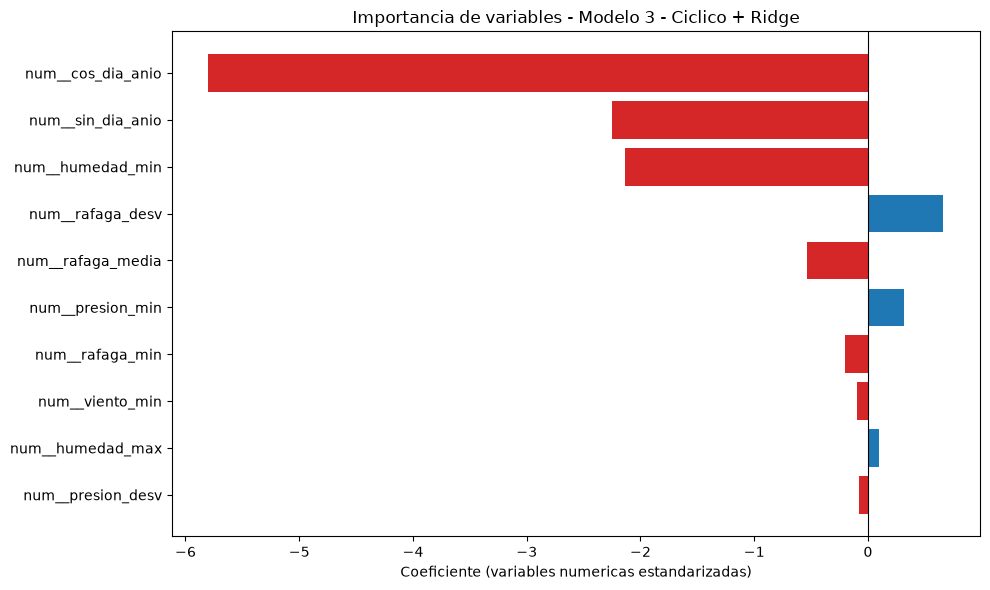

In [48]:
candidatos_finales = mejores_dos['Modelo'].tolist()
std_cv_por_modelo = {m: s for m, s in zip(resumen_cv['modelo'], resumen_cv['rmse_cv_std'])}
mejor_modelo_nombre = min(candidatos_finales, key=lambda m: std_cv_por_modelo[m])
mejor_pipeline = modelos_ajustados[mejor_modelo_nombre]

print("Dos mejores por RMSE de prueba:", candidatos_finales)
print("Desviacion CV de cada uno:", {m: round(std_cv_por_modelo[m], 3) for m in candidatos_finales})
print("Modelo final seleccionado (menor desviacion CV):", mejor_modelo_nombre)

if hasattr(mejor_pipeline.named_steps['reg'], 'alpha_'):
    print("Alpha (regularizacion) elegido por RidgeCV:", mejor_pipeline.named_steps['reg'].alpha_)

nombres_features = mejor_pipeline.named_steps['prep'].get_feature_names_out()
coeficientes = mejor_pipeline.named_steps['reg'].coef_

tabla_coef = pd.DataFrame({
    'variable': nombres_features,
    'coeficiente': coeficientes,
})
tabla_coef['importancia_abs'] = tabla_coef['coeficiente'].abs()
tabla_coef = tabla_coef.sort_values('importancia_abs', ascending=False).reset_index(drop=True)

display(tabla_coef)

plt.figure(figsize=(10, 6))
top_coef = tabla_coef.head(15).iloc[::-1]
colores_barras = ['tab:red' if c < 0 else 'tab:blue' for c in top_coef['coeficiente']]
plt.barh(top_coef['variable'], top_coef['coeficiente'], color=colores_barras)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente (variables numericas estandarizadas)')
plt.title(f'Importancia de variables - {mejor_modelo_nombre}')
plt.tight_layout()
plt.show()

Así se leen los coeficientes del Modelo 3 (todas sus variables numéricas están estandarizadas con z-score). Cuando el predictor está en z-score, cada coeficiente representa el cambio esperado en la variable dependiente asociado a un aumento de una desviación estándar en ese predictor, manteniendo las demás variables constantes. Por ejemplo, el coeficiente de `humedad_min` (−2.14) se lee como: un aumento de una desviación estándar en la humedad mínima del día está asociado a una caída de 2.14 °C en la temperatura máxima del día siguiente, manteniendo el resto de variables fijas.

| Variable | Coeficiente | Lectura |
|---|---:|---|
| `cos_dia_anio` | −5.79 | Componente cíclica del día del año; domina el modelo porque la temperatura es fuertemente estacional (coincide con los η² altos de `mes`/`estacion_anio` de la sección 2.8). |
| `sin_dia_anio` | −2.25 | Segunda componente de la codificación cíclica; junto con `cos_dia_anio` reconstruye la curva suave de estacionalidad. |
| `humedad_min` | −2.14 | A menor humedad relativa mínima del día, mayor la temperatura máxima del día siguiente. Coincide con el signo negativo de correlación (r ≈ −0.59) que se había visto en 2.8: los días secos anteceden a días más calurosos. |
| `rafaga_desv` | +0.66 | Mayor variabilidad de ráfagas se asocia a temperaturas ligeramente más altas al día siguiente. |
| `rafaga_media` | −0.53 | Ráfagas medias más fuertes, asociadas al paso de sistemas frontales, preceden días algo más fríos. |
| `presion_min` | +0.32 | Presión mínima más alta, condiciones más estables o despejadas, se asocia a temperaturas más altas al día siguiente. |
| `rafaga_min`, `viento_min`, `humedad_max`, `presion_desv` | entre −0.20 y +0.08 | Aportes menores, consistentes en dirección con la intuición meteorológica pero de bajo peso individual. |

En conjunto, el modelo confirma lo que ya se veía en la exploración: la estacionalidad (fecha) y la humedad son, por mucho, los mejores predictores de la temperatura máxima del día siguiente en Jena. El resto de variables (viento, ráfaga, presión) aportan matices adicionales relacionados con el paso de sistemas meteorológicos, pero pesan bastante menos.

### 5.2 Validación de los supuestos de la regresión lineal

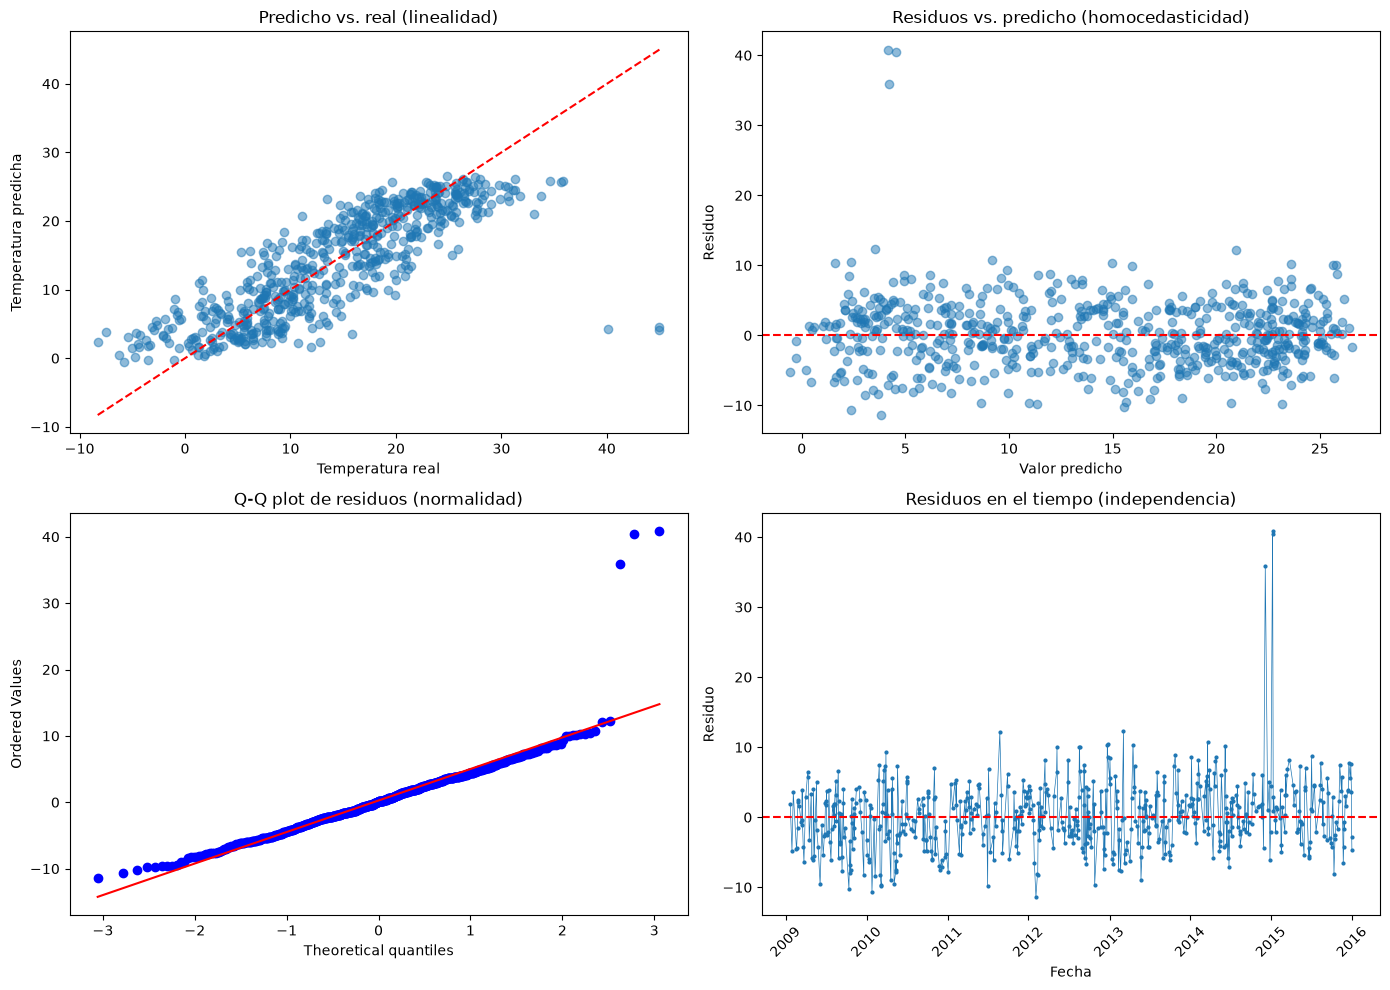

Shapiro-Wilk (normalidad de residuos): estadistico=0.8745, p-valor=6.679e-22
Durbin-Watson (residuos ordenados por fecha, independencia): 1.303  (cercano a 2 = sin autocorrelacion)


In [49]:
from scipy import stats

pred_mejor = mejor_pipeline.predict(X_test)
residuos = y_test.values - pred_mejor
fechas_test = data_modelo.loc[X_test.index, 'fecha']

orden = np.argsort(fechas_test.values)
residuos_orden = residuos[orden]
fechas_orden = fechas_test.values[orden]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(y_test, pred_mejor, alpha=0.5)
lims = [min(y_test.min(), pred_mejor.min()), max(y_test.max(), pred_mejor.max())]
axes[0, 0].plot(lims, lims, 'r--')
axes[0, 0].set_xlabel('Temperatura real')
axes[0, 0].set_ylabel('Temperatura predicha')
axes[0, 0].set_title('Predicho vs. real (linealidad)')

axes[0, 1].scatter(pred_mejor, residuos, alpha=0.5)
axes[0, 1].axhline(0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Valor predicho')
axes[0, 1].set_ylabel('Residuo')
axes[0, 1].set_title('Residuos vs. predicho (homocedasticidad)')

stats.probplot(residuos, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Q-Q plot de residuos (normalidad)')

axes[1, 1].plot(fechas_orden, residuos_orden, marker='o', markersize=2, linewidth=0.5)
axes[1, 1].axhline(0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Fecha')
axes[1, 1].set_ylabel('Residuo')
axes[1, 1].set_title('Residuos en el tiempo (independencia)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(residuos)
print(f"Shapiro-Wilk (normalidad de residuos): estadistico={shapiro_stat:.4f}, p-valor={shapiro_p:.4g}")

dw = np.sum(np.diff(residuos_orden) ** 2) / np.sum(residuos_orden ** 2)
print(f"Durbin-Watson (residuos ordenados por fecha, independencia): {dw:.3f}  (cercano a 2 = sin autocorrelacion)")

También se calcula el VIF (Variance Inflation Factor) de las variables numéricas del mejor modelo, para revisar si queda multicolinealidad relevante después de la selección de variables de la sección 3. Se usa como referencia: VIF ≤ 4 se considera sin multicolinealidad considerable.

In [50]:
def calcular_vif(df_numerico):
    resultados_vif = []
    for columna in df_numerico.columns:
        X_otras = df_numerico.drop(columns=[columna])
        y_col = df_numerico[columna]
        r2 = LinearRegression().fit(X_otras, y_col).score(X_otras, y_col)
        vif = 1 / (1 - r2) if r2 < 0.999999 else np.inf
        resultados_vif.append([columna, vif])
    return pd.DataFrame(resultados_vif, columns=['variable', 'VIF']).sort_values('VIF', ascending=False).reset_index(drop=True)


numericas_mejor_modelo = {
    'Modelo 1 - Base': numericas_m1,
    'Modelo 2 - Seleccion informada': numericas_m2,
    'Modelo 3 - Ciclico + Ridge': numericas_m3,
}[mejor_modelo_nombre]

print('VIF del Modelo 1 (todas las variables, sin tratar colinealidad) -- para contraste:')
tabla_vif_m1 = calcular_vif(X_train[numericas_m1])
display(tabla_vif_m1.head(6))

print(f'\nVIF del modelo final seleccionado ({mejor_modelo_nombre}):')
tabla_vif = calcular_vif(X_train[numericas_mejor_modelo])
display(tabla_vif)
print("\nRegla del curso: VIF <= 4 se considera sin multicolinealidad considerable.")

VIF del Modelo 1 (todas las variables, sin tratar colinealidad) -- para contraste:


,variable,VIF
0,presion_max,38.929491
1,presion_media,32.474745
2,presion_min,31.860735
3,humedad_min,19.140903
4,humedad_media,12.016767
5,humedad_desv,11.757220



VIF del modelo final seleccionado (Modelo 3 - Ciclico + Ridge):


,variable,VIF
0,rafaga_media,4.005701
1,rafaga_desv,2.603652
2,rafaga_min,2.152149
3,humedad_min,2.088493
4,cos_dia_anio,1.718172
5,humedad_max,1.513771
6,presion_desv,1.385910
7,presion_min,1.360685
8,viento_min,1.175162
9,sin_dia_anio,1.079009



Regla del curso: VIF <= 4 se considera sin multicolinealidad considerable.


Conclusión sobre los supuestos de la regresión lineal para el Modelo 3:

- Linealidad: el gráfico predicho vs. real muestra una nube razonablemente alineada con la diagonal, sin una curvatura sistemática evidente. El supuesto es razonable, aunque hay dispersión considerable en los extremos (temperaturas muy altas o muy bajas, donde el modelo tiende a subestimar o sobreestimar).
- Multicolinealidad (se usa como regla VIF ≤ 4 para descartar multicolinealidad considerable): el VIF de las 10 variables numéricas del Modelo 3 va de 1.08 a 4.01. Solo `rafaga_media` queda apenas por encima del umbral, prácticamente en el límite (4.01 vs. 4.00); el resto están claramente por debajo. Comparado con el VIF de 39 que alcanzaba `presion_max` en el Modelo 1 (calculado arriba para contraste directo), la selección informada de variables más la codificación cíclica resolvieron el problema de colinealidad detectado en la sección 2.8; lo que queda en el Modelo 3 es marginal.
- Normalidad de los residuos: el test de Shapiro-Wilk rechaza la normalidad (estadístico ≈ 0.875, p ≈ 6.7·10⁻²²), y el Q-Q plot muestra colas más pesadas que una normal. Con cerca de 618 observaciones de prueba esto no invalida las predicciones puntuales, pero sí implica que los intervalos de confianza clásicos sobre los coeficientes, que asumen normalidad, hay que tomarlos con cautela.
- Homocedasticidad: el gráfico de residuos vs. predicho no muestra un embudo marcado, aunque sí algo más de dispersión en temperaturas intermedias que en los extremos. No hay evidencia fuerte de heterocedasticidad severa.

Adicionalmente (no es uno de los supuestos clásicos más citados, pero es relevante por tratarse de una serie de tiempo):

- Independencia: el estadístico de Durbin-Watson (≈ 1.30, con los residuos ordenados por fecha) está por debajo de 2, lo que sugiere una autocorrelación positiva leve entre residuos de días consecutivos. Tiene sentido físico, porque los sistemas meteorológicos persisten varios días seguidos, así que el error del modelo en un día tiende a parecerse al del día siguiente. Es una limitación real de usar una partición aleatoria en vez de una partición temporal para series de tiempo, y se retoma en la pregunta de sesgos más abajo.

### 5.3 Preguntas de análisis de resultados

**1. ¿Cuál fue el valor de los diferentes coeficientes obtenidos en el mejor modelo?**

El mejor modelo (Modelo 3, estacionalidad cíclica más Ridge) usa 10 variables numéricas estandarizadas. De mayor a menor magnitud, sus coeficientes son: `cos_dia_anio` = −5.79, `sin_dia_anio` = −2.25, `humedad_min` = −2.14, `rafaga_desv` = +0.66, `rafaga_media` = −0.53, `presion_min` = +0.32, `rafaga_min` = −0.20, `viento_min` = −0.10, `humedad_max` = +0.09 y `presion_desv` = −0.08 (la tabla completa y su lectura están en la sección 5.1). Como todas las variables están estandarizadas, los coeficientes se pueden comparar directamente en magnitud: la estacionalidad (`cos_dia_anio` y `sin_dia_anio`) domina el modelo, seguida de la humedad mínima.

**2. A partir de la tabla comparativa, ¿cuál modelo ofrece el mejor rendimiento sobre el conjunto test? ¿Qué interpretación puedes darles a los valores obtenidos sobre las métricas de rendimiento?**

Por RMSE puntual sobre el conjunto de prueba interno, el Modelo 1 (4.95 °C) es marginalmente mejor que el Modelo 3 (5.08 °C), y ambos superan al Modelo 2 (5.19 °C). Un RMSE de ~5 °C y un MAE de ~3.6-3.7 °C significan que, en promedio, la predicción de la temperatura máxima del día siguiente se equivoca por unos pocos grados Celsius. Un R² de 0.66-0.69 indica que el modelo explica entre dos tercios y el 69% de la variabilidad de la temperatura, dejando un margen importante a la dinámica atmosférica de corto plazo que un modelo lineal con variables de un solo día no puede capturar. Como se explicó en la sección 5, se prefiere el Modelo 3 como modelo final a pesar de su RMSE puntual ligeramente mayor, porque es más estable entre particiones de validación cruzada y no sufre la multicolinealidad severa del Modelo 1 (VIF hasta 39 frente al umbral de 4 que recomienda el curso, contra un máximo de 4.01, prácticamente en el límite, en el Modelo 3), lo que lo hace más confiable para interpretar y para generalizar.

**3. ¿Cuáles variables fueron seleccionadas con el modelo seleccionado? A partir de estas, ¿qué interpretación de cara al problema puedes dar? Reflexiona sobre cómo este nuevo conocimiento podría ayudar a tomar decisiones en el contexto del problema.**

El Modelo 3 usa la estacionalidad cíclica (`sin_dia_anio`, `cos_dia_anio`), humedad (`humedad_min`, `humedad_max`), presión (`presion_min`, `presion_desv`), viento (`viento_min`) y ráfaga (`rafaga_media`, `rafaga_min`, `rafaga_desv`). Que la estacionalidad domine es esperable y poco accionable por sí sola, porque es básicamente un calendario, pero confirma que cualquier estrategia de AlpesPlanck debe tener una línea base estacional. Lo más útil desde el punto de vista operativo es que la humedad mínima del día resulta ser el mejor predictor meteorológico "activo": los días secos anteceden a días más calurosos. Esto es directamente relevante para el objetivo del proyecto de mitigar incendios forestales: una racha de días con humedad mínima baja, combinada con el ascenso estacional esperado, es una señal temprana razonable de riesgo de incendio antes de que ocurra el pico de temperatura. Las variables de ráfaga y presión pesan menos, pero apuntan a que el paso de sistemas frontales (más viento o ráfaga, presión más baja) anticipa temperaturas más bajas al día siguiente, lo que también sirve para anticipar el fin de una ola de calor o la llegada de un frente frío.

**4. A partir del contexto y los datos compartidos, ¿cómo representar la regresión lineal de forma matemática? Indique el método utilizado y el proceso para resolverlo.**

Para cada día *i* se modela la temperatura máxima del día siguiente como una combinación lineal de las variables predictoras estandarizadas más un término de error:

`temp_max_manana_i = β₀ + β₁·x₁ᵢ + β₂·x₂ᵢ + ... + βₚ·xₚᵢ + εᵢ`

o en forma matricial, `y = Xβ + ε`, donde `y` es el vector de temperaturas objetivo, `X` es la matriz de diseño (una columna por variable predictora, más el intercepto) y `ε` es el error aleatorio que el modelo no explica. El Modelo 3 usa regresión Ridge (`RidgeCV`), una variante regularizada de mínimos cuadrados que en vez de minimizar solo la suma de errores al cuadrado, como hace la regresión lineal ordinaria (OLS), minimiza:

`Σ(yᵢ − ŷᵢ)² + α·Σβⱼ²`

es decir, la suma de errores cuadráticos más una penalización (`α`, alpha) sobre el tamaño de los coeficientes. Esto tiene solución cerrada `β = (XᵀX + αI)⁻¹Xᵀy`, a diferencia de la solución OLS `β = (XᵀX)⁻¹Xᵀy`, y es justamente lo que la hace más robusta frente a variables correlacionadas: cuando `XᵀX` es casi singular por colinealidad, sumarle `αI` estabiliza la inversión de la matriz. El valor de `α` no se fija a mano, `RidgeCV` prueba una grilla de valores (`np.logspace(-3, 3, 25)`) y elige, por validación cruzada dentro del conjunto de entrenamiento, el que minimiza el error de predicción. Para este modelo el valor elegido fue alpha ≈ 5.62.

**5. En el ciclo de machine learning ¿Qué tipos de sesgo podría afectar los resultados y por qué? Describe dos tipos de sesgo.**

Dos tipos de sesgo aplican claramente a este proyecto:

Sesgo de muestra: pasa cuando los datos de entrenamiento no representan a la población que el modelo debe servir, así que el modelo funciona bien con los datos de entrenamiento pero mal con datos reales. Aquí se ve como sub-cobertura: todos los datos vienen de una sola estación, Jena, Alemania, y de un rango de años limitado (2009-2015 en el train). El modelo aprende la relación entre humedad, presión, viento y temperatura de ese lugar y esa época, y no hay garantía de que cubra otras estaciones de AlpesPlanck, otros microclimas, o años futuros si el clima cambia, que es justo parte de la motivación del caso: fenómenos como El Niño y La Niña pueden desplazar las relaciones históricas que el modelo aprendió.

Sesgo de medición: pasa por errores sistemáticos en la forma de recopilar o medir los datos, que distorsionan el conjunto de entrenamiento y pueden hacer que el modelo aprenda asociaciones incorrectas. Es exactamente lo que se encontró en la sección 2: ráfagas de viento de -10000 m/s, humedad guardada como fracción en vez de porcentaje, presión con la coma decimal corrida, mínimos mayores que máximos. Se corrigieron antes de modelar, pero corregir e imputar los valores faltantes (interpolación temporal, mediana por mes) inevitablemente suaviza los datos reales que faltaban, lo que deja un rastro residual de este mismo sesgo: el modelo puede subestimar sistemáticamente eventos extremos, que son justo los más relevantes para el caso de uso de incendios forestales.

## 6. Comunicar los resultados

AlpesPlanck pidió un video de máximo 3 minutos, dirigido al ingeniero de machine learning que lidera su equipo, explicando los elementos más relevantes de este ejercicio. Se entrega como archivo aparte del notebook.

## 7. Uso del modelo

Se generan las predicciones sobre `DatosTestLab1.csv` (sin etiqueta) usando el mejor modelo. Algunos puntos importantes sobre cómo se hizo:

- Se aplica exactamente la misma función `preparar_datos()` de la sección 2.9, para que el archivo de prueba reciba la misma limpieza y las mismas correcciones que se justificaron en la sección 2.
- Para la imputación de valores faltantes por mediana se usan las medianas calculadas con todo el conjunto de datos etiquetado (`medianas_referencia_datos_etiquetados`, es decir `data1` completo, no una muestra del archivo de prueba). Esto es coherente porque el modelo final se reentrena con `data1` completo: en el momento de generar las predicciones de producción ya no existe una partición interna train/test, todo `data1` es "el entrenamiento". No se usa ninguna estadística calculada sobre `DatosTestLab1.csv`, el archivo sin etiqueta.
- No se eliminan filas ni duplicados del archivo de prueba (`quitar_duplicados=False`, `eliminar_incompletos=False`) y se mantiene el orden original (`mantener_orden_original=True`), porque hay que entregar una predicción para cada fila del archivo original, en el mismo orden.
- El modelo final se reentrena con todos los datos etiquetados disponibles (`X`, `y` completos, no solo `X_train`) antes de predecir, para aprovechar toda la información disponible.

In [51]:
from sklearn.base import clone

test_raw = pd.read_csv('./data/DatosTestLab1.csv')
print("Filas en el archivo de prueba original:", test_raw.shape[0])

test_preparado = preparar_datos(
    test_raw,
    mediana_referencia=medianas_referencia_datos_etiquetados,
    quitar_duplicados=False,
    eliminar_incompletos=False,
    mantener_orden_original=True,
)

test_preparado['sin_dia_anio'] = np.sin(2 * np.pi * test_preparado['dia_del_anio'] / 365.25)
test_preparado['cos_dia_anio'] = np.cos(2 * np.pi * test_preparado['dia_del_anio'] / 365.25)

X_prod = test_preparado.drop(columns=['fecha'])

print("Nulos restantes en X_prod tras la preparacion:")
print(X_prod.isna().sum()[X_prod.isna().sum() > 0])

modelo_final = clone(modelos[mejor_modelo_nombre])
modelo_final.fit(X, y)

predicciones_test = modelo_final.predict(X_prod)

resultado_test = test_raw.copy()
resultado_test['temp_max_manana_predicha'] = predicciones_test

ruta_salida = './data/DatosTestLab1_predicciones.csv'
resultado_test.to_csv(ruta_salida, index=False)

print(f"\nArchivo exportado en: {ruta_salida}")
print(f"Filas exportadas: {resultado_test.shape[0]} (deben ser {test_raw.shape[0]})")
resultado_test.head()

Filas en el archivo de prueba original: 364
Nulos restantes en X_prod tras la preparacion:
Series([], dtype: int64)

Archivo exportado en: ./data/DatosTestLab1_predicciones.csv
Filas exportadas: 364 (deben ser 364)


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana_predicha
0,01.01.2016,998.9860,995.57,1000.60,1.1082,96.1493,90.8,98.7,2.0034,0.9649,0.18,3.13,0.5552,1.7068,0.40,5.17,0.8415,-0.8328,0.0927,173.6501,144,2016,1,invierno,January,S,2.067892
1,02.01.2016,991.4241,989.27,995.51,1.9413,92.3236,85.8,96.8,2.6562,1.9886,0.21,4.01,1.0960,2.8128,0.52,5.37,1.3604,1.1161,0.6688,30.9301,144,2016,2,invierno,January,NE,2.351725
2,03.01.2016,984.0232,974.12,989.39,4.5841,83.6056,73.9,94.7,6.9967,2.4992,0.60,4.46,0.8034,3.9316,1.28,6.49,1.2558,-0.7923,1.2638,122.0847,144,2016,3,invierno,January,SE,2.105713
3,04.01.2016,968.2449,966.52,974.02,1.9034,85.4688,75.5,93.8,5.8148,2.0932,0.25,4.06,0.8433,3.4434,0.48,6.25,1.4544,-1.6217,0.7020,156.5944,144,2016,4,invierno,January,SE,2.312016
4,05.01.2016,970.0099,967.85,972.90,1.6668,94.3521,92.0,96.8,1.4253,1.8380,0.45,3.21,0.6245,2.4610,0.80,4.41,0.7284,1.6549,0.7109,23.2458,144,2016,5,invierno,January,NE,-0.210007


Antes de dar por buenas las predicciones conviene hacer una verificación de sentido común: revisar que sigan el patrón estacional esperado en el hemisferio norte, con meses de invierno fríos y meses de verano calurosos en Jena.

In [52]:
print("Resumen de las predicciones de temperatura maxima (grados C):")
display(resultado_test['temp_max_manana_predicha'].describe())

print("\nPromedio de la prediccion por mes (validacion de sentido comun estacional):")
promedio_por_mes = test_preparado.assign(
    prediccion=predicciones_test
).groupby('mes')['prediccion'].mean().reindex(
    ['enero', 'febrero', 'marzo', 'abril', 'mayo', 'junio',
     'julio', 'agosto', 'septiembre', 'octubre', 'noviembre', 'diciembre']
)
display(promedio_por_mes.round(2))

Resumen de las predicciones de temperatura maxima (grados C):


count    364.000000
mean      13.903452
std        7.746600
min       -0.768459
25%        6.513189
50%       13.426260
75%       21.412093
max       26.516798
Name: temp_max_manana_predicha, dtype: float64


Promedio de la prediccion por mes (validacion de sentido comun estacional):


mes
enero          7.69
febrero        8.60
marzo         11.03
abril         14.76
mayo          16.54
junio         19.18
julio         20.31
agosto        20.53
septiembre    16.85
octubre       12.95
noviembre     10.23
diciembre      7.94
Name: prediccion, dtype: float64

## 8. Uso de herramienta de IA generativa

- Para mostrar de mejor manera los datos

Prompt utilizado: ayudame a q por columna me diga cuánto faltan y cual es el porcentaje de los q faltan y a organizarlo en una tabla

### Codigo original

cols_con_null = []

for col in data.columns:
    if data[col].count() != len(data):
        cols_con_null.append(col)

cols_con_null

### Codigo modificado

cols_con_null = []

for col in data.columns:
    if data[col].count() != len(data):
        cols_con_null.append(col)

print('Columnas con valores nulos:', cols_con_null)
print('Cantidad de columnas con nulos:', len(cols_con_null))

nulls = []

for col in cols_con_null:
    nulos = data[col].isna().sum()
    porcentaje = nulos / len(data) * 100
    
    nulls.append([col, nulos, porcentaje])

tabla_nulls = pd.DataFrame(
    nulls,
    columns=['Columna', 'Valores nulos', 'Porcentaje (%)']
)

tabla_nulls['Porcentaje (%)'] = tabla_nulls['Porcentaje (%)'].round(2)

display(tabla_nulls)

---

### Uso adicional durante la construcción de los modelos (secciones 2.9, 3 a 5 y 7)

Declaración del uso: se usó Claude como asistente de programación. Se le pidió refactorizar la preparación de datos de la sección 2 en la función reutilizable `preparar_datos()` de la sección 2.9, generar el código inicial de los tres pipelines de regresión lineal de la sección 3 (selección de variables, `ColumnTransformer`, `Pipeline`, validación cruzada), ayudar con la implementación del código de evaluación cuantitativa de la sección 4 junto con la extracción de coeficientes y las gráficas de validación de supuestos de la sección 5, y generar el código para aplicar el modelo final sobre `DatosTestLab1.csv` y exportar las predicciones en la sección 7.

Segunda ronda, depuración a partir de una revisión de código independiente: el notebook generado también se revisó con este modelo, pidiéndole específicamente auditar el código en busca de errores y de fuentes de fuga de información. Esa revisión señaló, entre otros puntos, que la función `preparar_datos()` de la sección 2.9 no reproducía exactamente `data1`, y que la imputación de nulos se calculaba sobre el conjunto completo antes de la partición train/test de la sección 3, lo que introduce una fuga leve. Se le pidió a Claude verificar cada observación contra el notebook real, en vez de asumirlas como ciertas, y corregir solo las que se confirmaran. Se encontró y corrigió la causa exacta del primer problema (un desempate distinto de fechas duplicadas al ordenar antes o después de quitar duplicados, ver la celda de `preparar_datos()`), y se reestructuró la sección 3 para particionar antes de imputar, imputando cada partición solo con sus propios vecinos temporales. Se midió el impacto del cambio: 2.31% de las celdas imputadas cambiaron de valor, con un efecto mínimo en el RMSE final.

Análisis crítico del resultado: el código generado para los pipelines de las secciones 3 y 4, y para las gráficas de diagnóstico de la sección 5, corrió bien desde la primera ejecución y su lógica es estándar (`Pipeline` y `ColumnTransformer` de scikit-learn). Pero eso no lo hacía automáticamente correcto: al someterlo a una segunda revisión independiente aparecieron dos errores reales que la primera pasada no había detectado. El primero era de reproducibilidad: la función `preparar_datos()` de la sección 2.9 no generaba exactamente los mismos valores que `data1`, por una diferencia de orden al desempatar fechas repetidas antes de interpolar. Era un error silencioso, no arrojaba ningún error de ejecución, solo números ligeramente distintos. El segundo era de metodología: la imputación de nulos se calculaba sobre el conjunto de datos completo antes de partir entrenamiento y prueba, lo que es una fuga de información hacia la evaluación del modelo. Ninguno de los dos hallazgos se aceptó solo porque la IA lo dijera. Se le pidió verificar cada uno contra el notebook real y mostrar evidencia (la fila exacta donde fallaba la reproducción, el número exacto de celdas afectadas por la fuga) antes de aplicar cualquier corrección, y de hecho algunas otras observaciones de esa segunda revisión resultaron exageradas o ya estaban cubiertas, así que no se aplicaron. Los conceptos de multicolinealidad y VIF, fuga de información y estabilidad en validación cruzada, vistos en el curso, fueron los que permitieron entender por qué esos dos hallazgos sí importaban y decidir cómo corregirlos.